<a href="https://colab.research.google.com/github/Gangojal/Pranjal2413/blob/main/FMCG_Discounting_and_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df=pd.read_csv("/content/fmcg_sales_3years_1M_rows.csv")

In [2]:
df.head()

,date,year,month,day,weekofyear,weekday,is_weekend,is_holiday,temperature,rain_mm,...,discount_pct,promo_flag,gross_sales,net_sales,stock_on_hand,stock_out_flag,lead_time_days,supplier_id,purchase_cost,margin_pct
0,2021-01-01,2021,1,1,53,4,0,1,8.44,1.24,...,0.1,1,167.84,151.06,248,0,11,S008,7.53,0.182
1,2021-01-02,2021,1,2,53,5,1,0,12.61,1.12,...,0.0,0,125.88,125.88,238,0,6,S057,5.19,0.505
2,2021-01-03,2021,1,3,53,6,1,0,12.02,2.69,...,0.3,1,398.62,279.03,238,0,6,S017,5.59,0.168
3,2021-01-04,2021,1,4,1,0,0,0,7.76,4.65,...,0.0,0,83.92,83.92,216,0,7,S012,7.81,0.255
4,2021-01-05,2021,1,5,1,1,0,0,11.16,1.77,...,0.2,1,178.33,142.66,372,0,8,S038,7.62,0.073


In [3]:
for i, col in enumerate(df.columns, 1):
    print(i, col)

1 date
2 year
3 month
4 day
5 weekofyear
6 weekday
7 is_weekend
8 is_holiday
9 temperature
10 rain_mm
11 store_id
12 country
13 city
14 channel
15 latitude
16 longitude
17 sku_id
18 sku_name
19 category
20 subcategory
21 brand
22 units_sold
23 list_price
24 discount_pct
25 promo_flag
26 gross_sales
27 net_sales
28 stock_on_hand
29 stock_out_flag
30 lead_time_days
31 supplier_id
32 purchase_cost
33 margin_pct


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nNumber of unique values:")
for col in df.columns:
    print(f"{col:20s} : {df[col].nunique():,}")

Rows: 1100000
Columns: 33

Number of unique values:
date                 : 1,095
year                 : 3
month                : 12
day                  : 31
weekofyear           : 53
weekday              : 7
is_weekend           : 2
is_holiday           : 2
temperature          : 710
rain_mm              : 559
store_id             : 13
country              : 7
city                 : 9
channel              : 4
latitude             : 13
longitude            : 13
sku_id               : 102
sku_name             : 102
category             : 5
subcategory          : 17
brand                : 6
units_sold           : 516
list_price           : 99
discount_pct         : 5
promo_flag           : 2
gross_sales          : 15,354
net_sales            : 29,938
stock_on_hand        : 640
stock_out_flag       : 2
lead_time_days       : 17
supplier_id          : 60
purchase_cost        : 1,062
margin_pct           : 601


In [5]:
df.groupby("country")["store_id"].nunique().sort_values(ascending=False)

,store_id
country,
Italy,4
Spain,3
Germany,2
France,1
Austria,1
Netherlands,1
Poland,1


In [6]:
df.groupby(["country", "city"])["store_id"].nunique()

country      city     
Austria      Vienna       1
France       Paris        1
Germany      Berlin       2
Italy        Milan        2
             Rome         2
Netherlands  Amsterdam    1
Poland       Warsaw       1
Spain        Barcelona    2
             Madrid       1
Name: store_id, dtype: int64

In [7]:
print("Expected full panel:",
      df["sku_id"].nunique()
      * df["store_id"].nunique()
      * df["date"].nunique())

print("Actual rows:", len(df))

Expected full panel: 1451970
Actual rows: 1100000


In [8]:
print(
    "Unique SKU-Store-Date:",
    df[["sku_id", "store_id", "date"]].drop_duplicates().shape[0]
)

print(
    "Unique SKU-Store-Channel-Date:",
    df[["sku_id", "store_id", "channel", "date"]]
      .drop_duplicates()
      .shape[0]
)

print(
    "Total rows:",
    len(df)
)

Unique SKU-Store-Date: 1100000
Unique SKU-Store-Channel-Date: 1100000
Total rows: 1100000


In [9]:
df.groupby("sku_id")["brand"].nunique().value_counts()

,count
brand,
1,102


In [10]:
df.groupby("store_id")["channel"].nunique()

,channel
store_id,
STORE0001,1
STORE0002,1
STORE0003,1
STORE0004,1
STORE0005,1
STORE0006,1
STORE0007,1
STORE0008,1
STORE0009,1


In [11]:
df.groupby(["store_id", "country", "city"])["channel"].unique()

,,,channel
store_id,country,city,
STORE0001,Germany,Berlin,[Hypermarket]
STORE0002,Italy,Rome,[Supermarket]
STORE0003,Italy,Milan,[Supermarket]
STORE0004,Germany,Berlin,[Hypermarket]
STORE0005,Poland,Warsaw,[Hypermarket]
STORE0006,France,Paris,[Hypermarket]
STORE0007,Spain,Barcelona,[Supermarket]
STORE0008,Austria,Vienna,[Hypermarket]
STORE0009,Spain,Barcelona,[E-commerce]


In [12]:
# Columns we don't need for the initial discount-trap analysis
drop_cols = [
    "temperature",
    "rain_mm",
    "latitude",
    "longitude",
    "lead_time_days",
    "supplier_id",
    "channel",
    "sku_name"
]

# Create clean dataset
df_clean = df.drop(columns=drop_cols).copy()

print("Original shape:", df.shape)
print("Clean shape:", df_clean.shape)

print("\nRemaining columns:")
for i, col in enumerate(df_clean.columns, 1):
    print(i, col)

Original shape: (1100000, 33)
Clean shape: (1100000, 25)

Remaining columns:
1 date
2 year
3 month
4 day
5 weekofyear
6 weekday
7 is_weekend
8 is_holiday
9 store_id
10 country
11 city
12 sku_id
13 category
14 subcategory
15 brand
16 units_sold
17 list_price
18 discount_pct
19 promo_flag
20 gross_sales
21 net_sales
22 stock_on_hand
23 stock_out_flag
24 purchase_cost
25 margin_pct


In [13]:
# Basic structure
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

print("\nDate range:")
print(df_clean["date"].min(), "to", df_clean["date"].max())

print("\nUnique entities:")
print("Stores:", df_clean["store_id"].nunique())
print("Countries:", df_clean["country"].nunique())
print("Cities:", df_clean["city"].nunique())
print("SKUs:", df_clean["sku_id"].nunique())
print("Brands:", df_clean["brand"].nunique())
print("Categories:", df_clean["category"].nunique())
print("Subcategories:", df_clean["subcategory"].nunique())

Rows: 1100000
Columns: 25

Date range:
2021-01-01 to 2023-12-31

Unique entities:
Stores: 13
Countries: 7
Cities: 9
SKUs: 102
Brands: 6
Categories: 5
Subcategories: 17


In [14]:
missing = (
    df_clean.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_pct = (
    df_clean.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
})

print(missing_table)

                missing_count  missing_pct
date                        0          0.0
year                        0          0.0
month                       0          0.0
day                         0          0.0
weekofyear                  0          0.0
weekday                     0          0.0
is_weekend                  0          0.0
is_holiday                  0          0.0
store_id                    0          0.0
country                     0          0.0
city                        0          0.0
sku_id                      0          0.0
category                    0          0.0
subcategory                 0          0.0
brand                       0          0.0
units_sold                  0          0.0
list_price                  0          0.0
discount_pct                0          0.0
promo_flag                  0          0.0
gross_sales                 0          0.0
net_sales                   0          0.0
stock_on_hand               0          0.0
stock_out_f

In [15]:
print("Discount levels:")
print(
    df_clean["discount_pct"]
    .value_counts()
    .sort_index()
)

Discount levels:
discount_pct
0.00    1011743
0.10      22274
0.15      22367
0.20      22086
0.30      21530
Name: count, dtype: int64


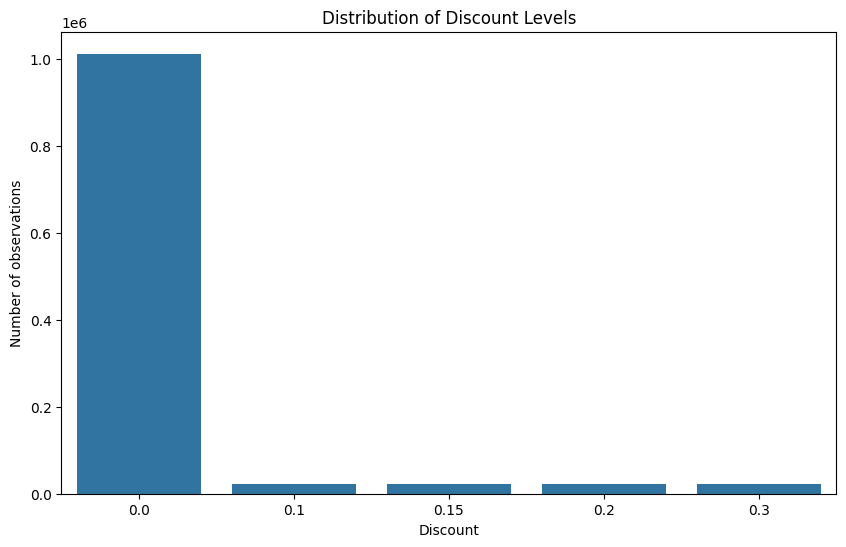

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.countplot(
    data=df_clean,
    x="discount_pct"
)

plt.xlabel("Discount")
plt.ylabel("Number of observations")
plt.title("Distribution of Discount Levels")

plt.show()

In [17]:
discount_economics = (
    df_clean
    .groupby("discount_pct")
    .agg(
        observations=("units_sold", "size"),
        avg_units=("units_sold", "mean"),
        median_units=("units_sold", "median"),
        avg_gross_sales=("gross_sales", "mean"),
        avg_net_sales=("net_sales", "mean"),
        avg_margin=("margin_pct", "mean"),
        avg_purchase_cost=("purchase_cost", "mean"),
        avg_stock=("stock_on_hand", "mean"),
        stockout_rate=("stock_out_flag", "mean")
    )
    .reset_index()
)

discount_economics["observation_share"] = (
    discount_economics["observations"] / len(df_clean) * 100
)

discount_economics["stockout_rate"] *= 100

print(discount_economics.to_string(index=False))

 discount_pct  observations  avg_units  median_units  avg_gross_sales  avg_net_sales  avg_margin  avg_purchase_cost  avg_stock  stockout_rate  observation_share
         0.00       1011743  55.264665          46.0       418.631605     418.631605    0.400200           4.661472 299.503330       3.004814          91.976636
         0.10         22274  94.332046          80.0       609.060922     548.154809    0.300445           4.151801 298.728922       3.066355           2.024909
         0.15         22367 100.301560          87.0       679.194571     577.315278    0.250235           4.232091 299.564805       3.250324           2.033364
         0.20         22086 106.695282          91.0       709.108147     567.286506    0.200451           4.211749 299.453772       2.861541           2.007818
         0.30         21530 116.176266          99.0       779.468079     545.627321    0.099796           4.260636 298.877984       3.116582           1.957273


In [18]:
sku_store_discount = (
    df_clean
    .groupby(["sku_id", "store_id", "discount_pct"])
    .agg(
        avg_units=("units_sold", "mean"),
        observations=("units_sold", "size")
    )
    .reset_index()
)

print(sku_store_discount.head(20))

     sku_id   store_id  discount_pct   avg_units  observations
0   SKU0001  STORE0001          0.00  125.897260           876
1   SKU0001  STORE0001          0.10  205.423729            59
2   SKU0001  STORE0001          0.15  234.769231            52
3   SKU0001  STORE0001          0.20  227.245902            61
4   SKU0001  STORE0001          0.30  252.212766            47
5   SKU0001  STORE0002          0.00   90.019406           876
6   SKU0001  STORE0002          0.10  155.864407            59
7   SKU0001  STORE0002          0.15  155.134615            52
8   SKU0001  STORE0002          0.20  163.426230            61
9   SKU0001  STORE0002          0.30  187.021277            47
10  SKU0001  STORE0003          0.00   87.987443           876
11  SKU0001  STORE0003          0.10  155.271186            59
12  SKU0001  STORE0003          0.15  158.730769            52
13  SKU0001  STORE0003          0.20  180.409836            61
14  SKU0001  STORE0003          0.30  191.744681       

In [19]:
# Create copy
df = df_clean.copy()

# ---------------------------------------------------------
# Create substitute/competitive group within each STORE
# based ONLY on SUBCATEGORY
# ---------------------------------------------------------

df["substitute_group"] = (
    df.groupby("store_id")["subcategory"]
      .transform(
          lambda x: pd.factorize(x)[0] + 1
      )
)

# ---------------------------------------------------------
# Check unique SKU mapping
# ---------------------------------------------------------

sku_groups = (
    df[
        [
            "store_id",
            "sku_id",
            "subcategory",
            "brand",
            "substitute_group"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "store_id",
            "substitute_group",
            "sku_id"
        ]
    )
)

print(sku_groups.head(50))

        store_id   sku_id   subcategory   brand  substitute_group
0      STORE0001  SKU0086       Shampoo  BrandB                 1
68985  STORE0001  SKU0087       Shampoo  BrandC                 1
75555  STORE0001  SKU0090       Shampoo  BrandF                 1
20805  STORE0001  SKU0014         Water  BrandB                 2
26280  STORE0001  SKU0015         Water  BrandC                 2
1095   STORE0001  SKU0016         Water  BrandD                 2
83220  STORE0001  SKU0017         Water  BrandE                 2
9855   STORE0001  SKU0018         Water  BrandF                 2
2190   STORE0001  SKU0049        Yogurt  BrandA                 3
10950  STORE0001  SKU0050        Yogurt  BrandB                 3
13140  STORE0001  SKU0051        Yogurt  BrandC                 3
58035  STORE0001  SKU0053        Yogurt  BrandE                 3
35040  STORE0001  SKU0054        Yogurt  BrandF                 3
51465  STORE0001  SKU0031     Chocolate  BrandA                 4
14235  STO

In [20]:
df["substitute_group"] = (
    df.groupby("store_id")["subcategory"]
      .transform(
          lambda x: pd.factorize(
              x,
              sort=True
          )[0] + 1
      )
)

In [21]:
# Check that each Store × Subcategory has exactly one group
check = (
    df.groupby(
        ["store_id", "subcategory"]
    )["substitute_group"]
    .nunique()
)

print(check.value_counts())

substitute_group
1    220
Name: count, dtype: int64


DATA QUALITY CHECK
Duplicate SKU-store-date rows: 0

Discount format detected: 0–1

DATASET
Rows: 1100000
SKUs: 102
Stores: 13
Date range: 2021-01-01 00:00:00 to 2023-12-31 00:00:00
Average daily discount: 1.5 %

DATE GAP CHECK
days_since_previous
1.0    1098995
Name: count, dtype: int64

PROMOTION EVENTS
Promotion introductions: 70096
Promotion removals: 70129

EVENT DATASET
event_type
Promotion Removal         70129
Promotion Introduction    70096
Name: count, dtype: int64

VALID EVENT WINDOWS
1-day valid events: 139766
3-day valid events: 139519
7-day valid events: 138419

PRIMARY 3-DAY SAMPLE
Introduction events: 69757
Removal events: 69762

PRIMARY RESULT
Introduction mean magnitude: 12.93%
Removal mean magnitude: 10.59%
Introduction median magnitude: 4.50%
Removal median magnitude: 17.29%
Median difference: 12.79 percentage points

MANN-WHITNEY TEST
H0: Removal response <= Introduction response
H1: Removal response > Introduction response
Statistic: 2660972086.0
One-sided p-value

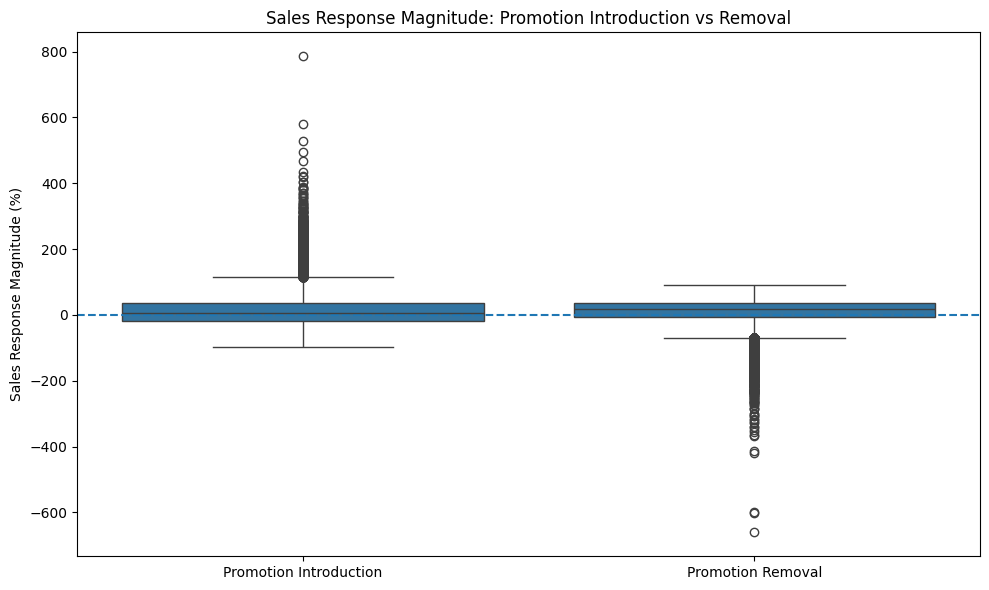

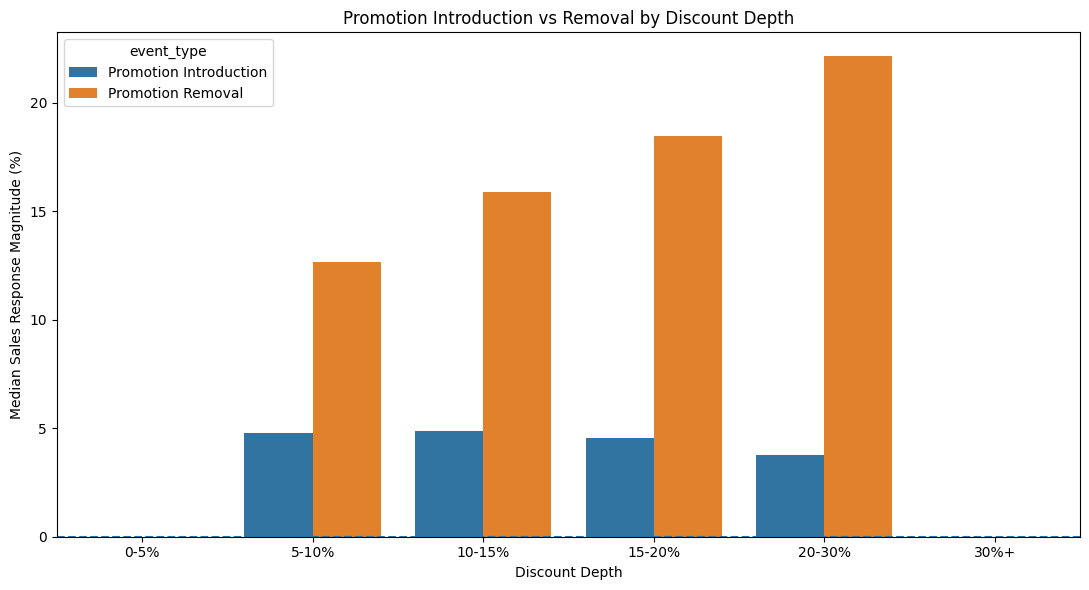

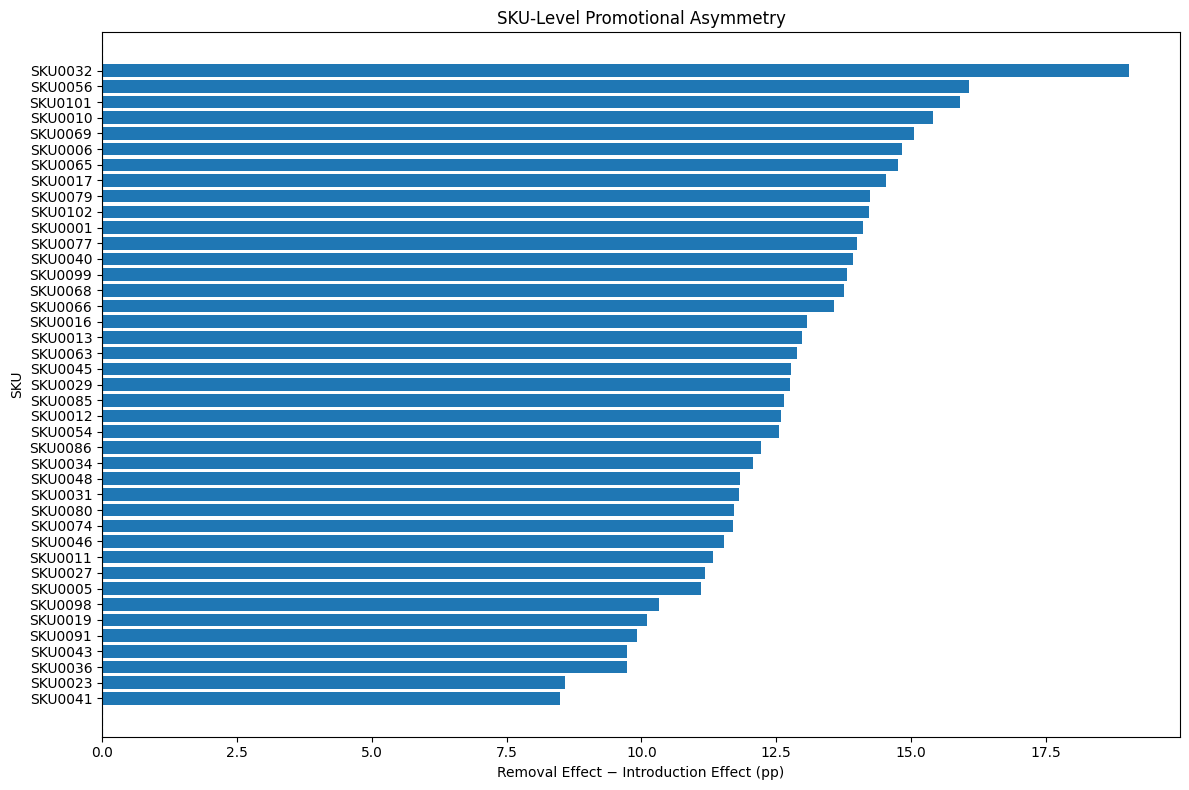



FINAL BEHAVIORAL ECONOMICS HYPOTHESIS

H0:
The sales response to promotion removal is
NOT larger than the response to promotion introduction.

H1:
The sales response to promotion removal IS
larger in magnitude than the response to
promotion introduction.


Introduction median magnitude: 4.50%
Removal median magnitude: 17.29%
Difference: 12.79 percentage points
Mann-Whitney p-value: 0.000000
Bootstrap 95% CI: [12.35, 13.24]

VERDICT: H1 SUPPORTED


The magnitude of the sales response following
promotion removal is significantly greater than
the magnitude of the response following promotion
introduction.

The observed asymmetry is consistent with a
loss-aversion / reference-dependence explanation.

However, because the dataset contains aggregate
SKU-store observations rather than individual
consumer choices, this should be described as
evidence CONSISTENT WITH loss aversion rather
than proof of individual-level loss aversion.


FILES SAVED
1. loss_aversion_all_events.csv
2. loss_aversi

In [22]:
# ================================================================
# FMCG BEHAVIORAL ECONOMICS PROJECT
# ================================================================
#
# HYPOTHESIS:
#
# H1:
# The magnitude of the sales response to PROMOTION REMOVAL
# is greater than the magnitude of the sales response to
# PROMOTION INTRODUCTION.
#
# Behavioral interpretation:
# A larger negative response to losing a promotion than the
# positive response to gaining an equivalent promotion is
# consistent with loss aversion / reference dependence.
#
# IMPORTANT:
# We observe aggregate SKU-store sales, not individual consumers.
# Therefore, a positive result is CONSISTENT WITH loss aversion,
# but does not prove the psychological mechanism.
#
# ================================================================
# DATA REQUIRED IN df:
#
# sku_id
# store_id
# date
# units_sold
# discount_pct
#
# ================================================================


# ================================================================
# 1. IMPORT LIBRARIES
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats


# ================================================================
# 2. COPY ORIGINAL DATA
# ================================================================

data = df.copy()


# ================================================================
# 3. BASIC CLEANING
# ================================================================

required_columns = [
    "sku_id",
    "store_id",
    "date",
    "units_sold",
    "discount_pct"
]

missing_columns = [
    c for c in required_columns
    if c not in data.columns
]

if missing_columns:

    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )


data["date"] = pd.to_datetime(
    data["date"],
    errors="coerce"
)

data["units_sold"] = pd.to_numeric(
    data["units_sold"],
    errors="coerce"
)

data["discount_pct"] = pd.to_numeric(
    data["discount_pct"],
    errors="coerce"
)


data = data[
    data["date"].notna() &
    data["units_sold"].notna() &
    data["discount_pct"].notna()
].copy()


data = data[
    data["units_sold"] >= 0
].copy()


data = data[
    data["discount_pct"] >= 0
].copy()


# ================================================================
# 4. CHECK DUPLICATE SKU × STORE × DATE
# ================================================================

duplicate_count = (
    data
    .duplicated(
        subset=[
            "sku_id",
            "store_id",
            "date"
        ]
    )
    .sum()
)

print("=" * 70)
print("DATA QUALITY CHECK")
print("=" * 70)

print(
    "Duplicate SKU-store-date rows:",
    duplicate_count
)


if duplicate_count > 0:

    raise ValueError(
        f"""
There are {duplicate_count} duplicate
SKU × Store × Date observations.

Resolve duplicates before running the event study.
The analysis requires one observation per
SKU × Store × Date.
"""
    )


# ================================================================
# 5. STANDARDIZE DISCOUNT
#
# Some datasets store:
#
# 20 = 20%
#
# Others:
#
# 0.20 = 20%
#
# We convert everything to decimal form.
# ================================================================

max_discount = data[
    "discount_pct"
].max()


if max_discount > 1:

    print(
        "\nDiscount format detected: 0–100"
    )

    data["discount"] = (
        data["discount_pct"] / 100
    )

else:

    print(
        "\nDiscount format detected: 0–1"
    )

    data["discount"] = (
        data["discount_pct"]
    )


# Cap impossible discounts

data = data[
    data["discount"] <= 1
].copy()


# ================================================================
# 6. SORT
# ================================================================

group_cols = [
    "sku_id",
    "store_id"
]

data = data.sort_values(
    group_cols + ["date"]
).reset_index(drop=True)


# ================================================================
# 7. BASIC DATASET INFORMATION
# ================================================================

print("\n" + "=" * 70)
print("DATASET")
print("=" * 70)

print(
    "Rows:",
    len(data)
)

print(
    "SKUs:",
    data["sku_id"].nunique()
)

print(
    "Stores:",
    data["store_id"].nunique()
)

print(
    "Date range:",
    data["date"].min(),
    "to",
    data["date"].max()
)

print(
    "Average daily discount:",
    round(
        data["discount"].mean() * 100,
        2
    ),
    "%"
)


# ================================================================
# 8. CHECK PANEL DATE GAPS
# ================================================================

data["previous_date"] = (
    data
    .groupby(group_cols)["date"]
    .shift(1)
)

data["days_since_previous"] = (
    data["date"]
    -
    data["previous_date"]
).dt.days


print("\n" + "=" * 70)
print("DATE GAP CHECK")
print("=" * 70)

gap_distribution = (
    data["days_since_previous"]
    .value_counts()
    .sort_index()
    .head(20)
)

print(
    gap_distribution
)


# ================================================================
# 9. IDENTIFY PROMOTION TRANSITIONS
#
# We use a small tolerance rather than exact floating-point
# comparison.
# ================================================================

EPSILON = 1e-9


data["previous_discount"] = (
    data
    .groupby(group_cols)["discount"]
    .shift(1)
)


data["previous_is_promotion"] = (
    data["previous_discount"] > EPSILON
)


data["current_is_promotion"] = (
    data["discount"] > EPSILON
)


# ================================================================
# 10. PROMOTION INTRODUCTION
#
# Previous day = NO PROMOTION
# Current day  = PROMOTION
#
# And observations must be consecutive calendar days.
# ================================================================

data["promotion_introduction"] = (
    (data["days_since_previous"] == 1)
    &
    (~data["previous_is_promotion"])
    &
    (data["current_is_promotion"])
)


# ================================================================
# 11. PROMOTION REMOVAL
#
# Previous day = PROMOTION
# Current day  = NO PROMOTION
# ================================================================

data["promotion_removal"] = (
    (data["days_since_previous"] == 1)
    &
    (data["previous_is_promotion"])
    &
    (~data["current_is_promotion"])
)


# ================================================================
# 12. EVENT COUNTS
# ================================================================

number_introductions = (
    data["promotion_introduction"].sum()
)

number_removals = (
    data["promotion_removal"].sum()
)


print("\n" + "=" * 70)
print("PROMOTION EVENTS")
print("=" * 70)

print(
    "Promotion introductions:",
    number_introductions
)

print(
    "Promotion removals:",
    number_removals
)


# ================================================================
# 13. CREATE EVENT DATAFRAME
# ================================================================

start_events = data[
    data["promotion_introduction"]
].copy()


removal_events = data[
    data["promotion_removal"]
].copy()


# ================================================================
# 14. STANDARDIZE EVENT TABLE
# ================================================================

start_events["event_type"] = (
    "Promotion Introduction"
)

start_events["event_date"] = (
    start_events["date"]
)

start_events["discount_depth"] = (
    start_events["discount"]
)


removal_events["event_type"] = (
    "Promotion Removal"
)

removal_events["event_date"] = (
    removal_events["date"]
)

removal_events["discount_depth"] = (
    removal_events["previous_discount"]
)


event_columns = [
    "sku_id",
    "store_id",
    "event_date",
    "event_type",
    "discount_depth"
]


start_events = start_events[
    event_columns
].copy()


removal_events = removal_events[
    event_columns
].copy()


# ================================================================
# 15. COMBINE EVENTS
# ================================================================

events = pd.concat(
    [
        start_events,
        removal_events
    ],
    ignore_index=True
)


print("\n" + "=" * 70)
print("EVENT DATASET")
print("=" * 70)

print(
    events["event_type"].value_counts()
)


# ================================================================
# 16. CREATE DAILY SALES LOOKUP
#
# This contains ONLY the information required for event matching.
# ================================================================

sales_lookup = data[
    [
        "sku_id",
        "store_id",
        "date",
        "units_sold"
    ]
].copy()


# ================================================================
# 17. FUNCTION TO ADD EXACT CALENDAR-DAY SALES
#
# IMPORTANT:
#
# We do NOT use shift().
#
# Instead we merge on:
#
# SKU
# Store
# Exact calendar date
#
# Therefore:
#
# t-3 means exactly 3 calendar days before.
#
# ================================================================

def add_sales_for_offset(
    event_df,
    sales_df,
    offset,
    label
):

    temp = event_df[
        [
            "sku_id",
            "store_id",
            "event_date"
        ]
    ].copy()


    temp["lookup_date"] = (
        temp["event_date"]
        +
        pd.Timedelta(days=offset)
    )


    lookup = sales_df.rename(
        columns={
            "date": "lookup_date",
            "units_sold":
                f"{label}_{abs(offset)}d"
        }
    )


    temp = temp.merge(
        lookup[
            [
                "sku_id",
                "store_id",
                "lookup_date",
                f"{label}_{abs(offset)}d"
            ]
        ],
        on=[
            "sku_id",
            "store_id",
            "lookup_date"
        ],
        how="left"
    )


    return temp[
        [
            f"{label}_{abs(offset)}d"
        ]
    ]


# ================================================================
# 18. ADD PRE-EVENT AND POST-EVENT SALES
#
# We need:
#
# PRE:
# t-1, t-2, ... t-7
#
# POST:
# t+1, t+2, ... t+7
#
# ================================================================

event_base = events.copy()

event_base = event_base.reset_index(
    drop=True
)


# Unique event ID
event_base["event_id"] = (
    np.arange(len(event_base))
)


# We will use event_id for safe merging.

sales_key = sales_lookup.copy()


# ------------------------------------------------
# PRE-EVENT
# ------------------------------------------------

for k in range(1, 8):

    lookup = sales_key.rename(
        columns={
            "date": "lookup_date",
            "units_sold":
                f"pre_{k}d"
        }
    )


    temp = event_base[
        [
            "event_id",
            "sku_id",
            "store_id",
            "event_date"
        ]
    ].copy()


    temp["lookup_date"] = (
        temp["event_date"]
        -
        pd.Timedelta(days=k)
    )


    temp = temp.merge(
        lookup[
            [
                "sku_id",
                "store_id",
                "lookup_date",
                f"pre_{k}d"
            ]
        ],
        on=[
            "sku_id",
            "store_id",
            "lookup_date"
        ],
        how="left"
    )


    event_base = event_base.merge(
        temp[
            [
                "event_id",
                f"pre_{k}d"
            ]
        ],
        on="event_id",
        how="left"
    )


# ------------------------------------------------
# POST-EVENT
# ------------------------------------------------

for k in range(1, 8):

    lookup = sales_key.rename(
        columns={
            "date": "lookup_date",
            "units_sold":
                f"post_{k}d"
        }
    )


    temp = event_base[
        [
            "event_id",
            "sku_id",
            "store_id",
            "event_date"
        ]
    ].copy()


    temp["lookup_date"] = (
        temp["event_date"]
        +
        pd.Timedelta(days=k)
    )


    temp = temp.merge(
        lookup[
            [
                "sku_id",
                "store_id",
                "lookup_date",
                f"post_{k}d"
            ]
        ],
        on=[
            "sku_id",
            "store_id",
            "lookup_date"
        ],
        how="left"
    )


    event_base = event_base.merge(
        temp[
            [
                "event_id",
                f"post_{k}d"
            ]
        ],
        on="event_id",
        how="left"
    )


# ================================================================
# 19. CALCULATE PRE/POST WINDOWS
# ================================================================

event_base["pre_1d"] = (
    event_base["pre_1d"]
)

event_base["post_1d"] = (
    event_base["post_1d"]
)


event_base["pre_3d"] = (
    event_base[
        [
            "pre_1d",
            "pre_2d",
            "pre_3d"
        ]
    ]
    .mean(
        axis=1,
        skipna=False
    )
)


event_base["post_3d"] = (
    event_base[
        [
            "post_1d",
            "post_2d",
            "post_3d"
        ]
    ]
    .mean(
        axis=1,
        skipna=False
    )
)


event_base["pre_7d"] = (
    event_base[
        [
            "pre_1d",
            "pre_2d",
            "pre_3d",
            "pre_4d",
            "pre_5d",
            "pre_6d",
            "pre_7d"
        ]
    ]
    .mean(
        axis=1,
        skipna=False
    )
)


event_base["post_7d"] = (
    event_base[
        [
            "post_1d",
            "post_2d",
            "post_3d",
            "post_4d",
            "post_5d",
            "post_6d",
            "post_7d"
        ]
    ]
    .mean(
        axis=1,
        skipna=False
    )
)


# ================================================================
# 20. SALES RESPONSE
#
# (Post - Pre) / Pre × 100
#
# ================================================================

for window in [1, 3, 7]:

    pre = (
        event_base[
            f"pre_{window}d"
        ]
    )

    post = (
        event_base[
            f"post_{window}d"
        ]
    )


    event_base[
        f"response_{window}d"
    ] = np.where(

        pre > 0,

        (
            (
                post - pre
            )
            /
            pre
        )
        *
        100,

        np.nan
    )


# ================================================================
# 21. CHECK VALID EVENT COUNTS
# ================================================================

print("\n" + "=" * 70)
print("VALID EVENT WINDOWS")
print("=" * 70)

for window in [1, 3, 7]:

    col = (
        f"response_{window}d"
    )

    print(
        f"{window}-day valid events:",
        event_base[col].notna().sum()
    )


# ================================================================
# 22. PRIMARY 3-DAY SAMPLE
# ================================================================

analysis = event_base[
    event_base["response_3d"].notna()
].copy()


introduction = analysis[
    analysis["event_type"]
    ==
    "Promotion Introduction"
].copy()


removal = analysis[
    analysis["event_type"]
    ==
    "Promotion Removal"
].copy()


print("\n" + "=" * 70)
print("PRIMARY 3-DAY SAMPLE")
print("=" * 70)

print(
    "Introduction events:",
    len(introduction)
)

print(
    "Removal events:",
    len(removal)
)


# ================================================================
# 23. RESPONSE MAGNITUDE
#
# Introduction:
#
# +30% → +30
#
# Removal:
#
# -50% → +50
#
# ================================================================

introduction["response_magnitude"] = (
    introduction["response_3d"]
)

removal["response_magnitude"] = (
    -removal["response_3d"]
)


# ================================================================
# 24. PRIMARY DESCRIPTIVE RESULTS
# ================================================================

intro_median = (
    introduction[
        "response_magnitude"
    ].median()
)

removal_median = (
    removal[
        "response_magnitude"
    ].median()
)


intro_mean = (
    introduction[
        "response_magnitude"
    ].mean()
)

removal_mean = (
    removal[
        "response_magnitude"
    ].mean()
)


difference = (
    removal_median
    -
    intro_median
)


print("\n" + "=" * 70)
print("PRIMARY RESULT")
print("=" * 70)

print(
    f"Introduction mean magnitude: "
    f"{intro_mean:.2f}%"
)

print(
    f"Removal mean magnitude: "
    f"{removal_mean:.2f}%"
)

print(
    f"Introduction median magnitude: "
    f"{intro_median:.2f}%"
)

print(
    f"Removal median magnitude: "
    f"{removal_median:.2f}%"
)

print(
    f"Median difference: "
    f"{difference:.2f} percentage points"
)


# ================================================================
# 25. STATISTICAL TEST
#
# Mann-Whitney U:
#
# H0:
# Removal magnitude <= Introduction magnitude
#
# H1:
# Removal magnitude > Introduction magnitude
# ================================================================

intro_values = (
    introduction[
        "response_magnitude"
    ]
    .dropna()
    .values
)

removal_values = (
    removal[
        "response_magnitude"
    ]
    .dropna()
    .values
)


if (
    len(intro_values) >= 5
    and
    len(removal_values) >= 5
):

    mann_stat, mann_p = (
        stats.mannwhitneyu(
            removal_values,
            intro_values,
            alternative="greater"
        )
    )

else:

    mann_stat = np.nan
    mann_p = np.nan


print("\n" + "=" * 70)
print("MANN-WHITNEY TEST")
print("=" * 70)

print(
    "H0: Removal response <= Introduction response"
)

print(
    "H1: Removal response > Introduction response"
)

print(
    f"Statistic: {mann_stat}"
)

print(
    f"One-sided p-value: {mann_p}"
)


# ================================================================
# 26. BOOTSTRAP CONFIDENCE INTERVAL
#
# Difference in medians:
#
# median(removal)
# -
# median(introduction)
# ================================================================

np.random.seed(42)

bootstrap_differences = []

N_BOOTSTRAP = 5000


if (
    len(intro_values) >= 5
    and
    len(removal_values) >= 5
):

    for _ in range(N_BOOTSTRAP):

        intro_sample = np.random.choice(
            intro_values,
            size=len(intro_values),
            replace=True
        )

        removal_sample = np.random.choice(
            removal_values,
            size=len(removal_values),
            replace=True
        )


        bootstrap_differences.append(

            np.median(removal_sample)
            -
            np.median(intro_sample)

        )


    ci_low, ci_high = np.percentile(
        bootstrap_differences,
        [2.5, 97.5]
    )

else:

    ci_low = np.nan
    ci_high = np.nan


print("\n" + "=" * 70)
print("BOOTSTRAP 95% CI")
print("=" * 70)

print(
    f"Median difference: "
    f"{difference:.2f} pp"
)

print(
    f"95% CI: "
    f"[{ci_low:.2f}, {ci_high:.2f}]"
)


# ================================================================
# 27. DISCOUNT DEPTH BUCKETS
# ================================================================

discount_bins = [
    0,
    0.05,
    0.10,
    0.15,
    0.20,
    0.30,
    1.00
]


discount_labels = [
    "0-5%",
    "5-10%",
    "10-15%",
    "15-20%",
    "20-30%",
    "30%+"
]


analysis["discount_bucket"] = pd.cut(
    analysis["discount_depth"],
    bins=discount_bins,
    labels=discount_labels,
    include_lowest=True
)


analysis["response_magnitude"] = np.where(

    analysis["event_type"]
    ==
    "Promotion Introduction",

    analysis["response_3d"],

    -analysis["response_3d"]

)


# ================================================================
# 28. DISCOUNT DEPTH SUMMARY
# ================================================================

depth_summary = (
    analysis
    .groupby(
        [
            "discount_bucket",
            "event_type"
        ],
        observed=True
    )
    ["response_magnitude"]
    .agg(
        observations="count",
        mean="mean",
        median="median",
        std="std"
    )
    .reset_index()
)


print("\n" + "=" * 70)
print("RESULTS BY DISCOUNT DEPTH")
print("=" * 70)

print(
    depth_summary.to_string(
        index=False
    )
)


# ================================================================
# 29. WITHIN-DISCOUNT-BAND TEST
# ================================================================

depth_tests = []


for bucket in discount_labels:

    intro_bucket = analysis[
        (analysis["discount_bucket"] == bucket)
        &
        (
            analysis["event_type"]
            ==
            "Promotion Introduction"
        )
    ][
        "response_magnitude"
    ].dropna()


    removal_bucket = analysis[
        (analysis["discount_bucket"] == bucket)
        &
        (
            analysis["event_type"]
            ==
            "Promotion Removal"
        )
    ][
        "response_magnitude"
    ].dropna()


    if (
        len(intro_bucket) >= 5
        and
        len(removal_bucket) >= 5
    ):

        stat, p = stats.mannwhitneyu(
            removal_bucket,
            intro_bucket,
            alternative="greater"
        )


        depth_tests.append({

            "discount_bucket":
                bucket,

            "n_introduction":
                len(intro_bucket),

            "n_removal":
                len(removal_bucket),

            "introduction_median":
                intro_bucket.median(),

            "removal_median":
                removal_bucket.median(),

            "difference":
                (
                    removal_bucket.median()
                    -
                    intro_bucket.median()
                ),

            "p_value":
                p

        })


depth_tests = pd.DataFrame(
    depth_tests
)


print("\n" + "=" * 70)
print("STATISTICAL TEST BY DISCOUNT DEPTH")
print("=" * 70)

if len(depth_tests) > 0:

    print(
        depth_tests.to_string(
            index=False
        )
    )

else:

    print(
        "Not enough observations in the discount bands."
    )


# ================================================================
# 30. ROBUSTNESS ACROSS TIME WINDOWS
# ================================================================

robustness_results = []


for window in [1, 3, 7]:

    response_col = (
        f"response_{window}d"
    )


    intro = analysis[
        analysis["event_type"]
        ==
        "Promotion Introduction"
    ][response_col].dropna()


    rem = analysis[
        analysis["event_type"]
        ==
        "Promotion Removal"
    ][response_col].dropna()


    intro_mag = intro

    rem_mag = -rem


    if (
        len(intro_mag) >= 5
        and
        len(rem_mag) >= 5
    ):

        stat, p = stats.mannwhitneyu(
            rem_mag,
            intro_mag,
            alternative="greater"
        )


        robustness_results.append({

            "window":
                f"{window}-day",

            "introduction_n":
                len(intro_mag),

            "removal_n":
                len(rem_mag),

            "introduction_median":
                intro_mag.median(),

            "removal_median":
                rem_mag.median(),

            "difference":
                (
                    rem_mag.median()
                    -
                    intro_mag.median()
                ),

            "p_value":
                p

        })


robustness_results = pd.DataFrame(
    robustness_results
)


print("\n" + "=" * 70)
print("ROBUSTNESS")
print("=" * 70)

print(
    robustness_results.to_string(
        index=False
    )
)


# ================================================================
# 31. SKU-LEVEL RESULTS
# ================================================================

sku_intro = (
    introduction
    .groupby("sku_id")
    ["response_magnitude"]
    .median()
    .rename(
        "introduction_median"
    )
)


sku_removal = (
    removal
    .groupby("sku_id")
    ["response_magnitude"]
    .median()
    .rename(
        "removal_median"
    )
)


sku_results = pd.concat(
    [
        sku_intro,
        sku_removal
    ],
    axis=1
).reset_index()


sku_results["asymmetry"] = (
    sku_results["removal_median"]
    -
    sku_results["introduction_median"]
)


sku_results["removal_larger"] = (
    sku_results["asymmetry"] > 0
)


print("\n" + "=" * 70)
print("SKU-LEVEL RESULTS")
print("=" * 70)

print(
    sku_results
    .sort_values(
        "asymmetry",
        ascending=False
    )
    .to_string(
        index=False
    )
)


# ================================================================
# 32. SKU CONSISTENCY
# ================================================================

if len(sku_results) > 0:

    sku_support_rate = (
        sku_results["removal_larger"]
        .mean()
        * 100
    )

else:

    sku_support_rate = np.nan


print("\n" + "=" * 70)
print("SKU CONSISTENCY")
print("=" * 70)

print(
    f"Percentage of SKUs where "
    f"removal response > introduction response: "
    f"{sku_support_rate:.2f}%"
)


# ================================================================
# 33. STORE-LEVEL RESULTS
# ================================================================

store_intro = (
    introduction
    .groupby("store_id")
    ["response_magnitude"]
    .median()
    .rename(
        "introduction_median"
    )
)


store_removal = (
    removal
    .groupby("store_id")
    ["response_magnitude"]
    .median()
    .rename(
        "removal_median"
    )
)


store_results = pd.concat(
    [
        store_intro,
        store_removal
    ],
    axis=1
).reset_index()


store_results["asymmetry"] = (
    store_results["removal_median"]
    -
    store_results["introduction_median"]
)


print("\n" + "=" * 70)
print("STORE-LEVEL RESULTS")
print("=" * 70)

print(
    store_results.to_string(
        index=False
    )
)


# ================================================================
# 34. PLOT 1 — OVERALL DISTRIBUTION
# ================================================================

plot_data = pd.concat(
    [
        introduction[
            ["response_magnitude"]
        ].assign(
            Event="Promotion Introduction"
        ),

        removal[
            ["response_magnitude"]
        ].assign(
            Event="Promotion Removal"
        )
    ],
    ignore_index=True
)


plt.figure(
    figsize=(10, 6)
)

sns.boxplot(
    data=plot_data,
    x="Event",
    y="response_magnitude"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "Sales Response Magnitude: Promotion Introduction vs Removal"
)

plt.ylabel(
    "Sales Response Magnitude (%)"
)

plt.xlabel("")

plt.tight_layout()

plt.show()


# ================================================================
# 35. PLOT 2 — DISCOUNT DEPTH
# ================================================================

if len(depth_summary) > 0:

    plt.figure(
        figsize=(11, 6)
    )

    sns.barplot(
        data=depth_summary,
        x="discount_bucket",
        y="median",
        hue="event_type"
    )

    plt.axhline(
        0,
        linestyle="--"
    )

    plt.xlabel(
        "Discount Depth"
    )

    plt.ylabel(
        "Median Sales Response Magnitude (%)"
    )

    plt.title(
        "Promotion Introduction vs Removal by Discount Depth"
    )

    plt.tight_layout()

    plt.show()


# ================================================================
# 36. PLOT 3 — SKU ASYMMETRY
# ================================================================

if len(sku_results) > 0:

    sku_plot = (
        sku_results
        .sort_values(
            "asymmetry"
        )
    )


    plt.figure(
        figsize=(12, 8)
    )

    plt.barh(
        sku_plot["sku_id"].astype(str),
        sku_plot["asymmetry"]
    )

    plt.axvline(
        0,
        linestyle="--"
    )

    plt.xlabel(
        "Removal Effect − Introduction Effect (pp)"
    )

    plt.ylabel(
        "SKU"
    )

    plt.title(
        "SKU-Level Promotional Asymmetry"
    )

    plt.tight_layout()

    plt.show()


# ================================================================
# 37. FINAL HYPOTHESIS VERDICT
# ================================================================

print("\n")
print("=" * 70)
print("FINAL BEHAVIORAL ECONOMICS HYPOTHESIS")
print("=" * 70)

print(
    """
H0:
The sales response to promotion removal is
NOT larger than the response to promotion introduction.

H1:
The sales response to promotion removal IS
larger in magnitude than the response to
promotion introduction.
"""
)


print(
    f"\nIntroduction median magnitude: "
    f"{intro_median:.2f}%"
)

print(
    f"Removal median magnitude: "
    f"{removal_median:.2f}%"
)

print(
    f"Difference: "
    f"{difference:.2f} percentage points"
)

print(
    f"Mann-Whitney p-value: "
    f"{mann_p:.6f}"
)

print(
    f"Bootstrap 95% CI: "
    f"[{ci_low:.2f}, {ci_high:.2f}]"
)


# ================================================================
# DECISION
# ================================================================

if (
    difference > 0
    and
    mann_p < 0.05
    and
    ci_low > 0
):

    verdict = (
        "H1 SUPPORTED"
    )


    explanation = """

The magnitude of the sales response following
promotion removal is significantly greater than
the magnitude of the response following promotion
introduction.

The observed asymmetry is consistent with a
loss-aversion / reference-dependence explanation.

However, because the dataset contains aggregate
SKU-store observations rather than individual
consumer choices, this should be described as
evidence CONSISTENT WITH loss aversion rather
than proof of individual-level loss aversion.
"""


elif difference > 0:

    verdict = (
        "DESCRIPTIVE SUPPORT ONLY"
    )


    explanation = """

Promotion removal has a larger response magnitude
than promotion introduction descriptively, but the
statistical evidence is not strong enough to reject
the null hypothesis.

The result is suggestive but not conclusive.
"""


else:

    verdict = (
        "H1 NOT SUPPORTED"
    )


    explanation = """

The magnitude of the response to promotion removal
is not greater than the response to promotion
introduction.

The proposed asymmetric behavioral response is
therefore not supported by this dataset.
"""


print(
    "\nVERDICT:",
    verdict
)

print(
    explanation
)


# ================================================================
# 38. SAVE RESULTS
# ================================================================

events.to_csv(
    "loss_aversion_all_events.csv",
    index=False
)

analysis.to_csv(
    "loss_aversion_event_analysis.csv",
    index=False
)

depth_summary.to_csv(
    "loss_aversion_discount_depth.csv",
    index=False
)

depth_tests.to_csv(
    "loss_aversion_discount_tests.csv",
    index=False
)

robustness_results.to_csv(
    "loss_aversion_robustness.csv",
    index=False
)

sku_results.to_csv(
    "loss_aversion_sku_results.csv",
    index=False
)

store_results.to_csv(
    "loss_aversion_store_results.csv",
    index=False
)


# ================================================================
# 39. FINAL FILE LIST
# ================================================================

print("\n" + "=" * 70)
print("FILES SAVED")
print("=" * 70)

print(
    "1. loss_aversion_all_events.csv"
)

print(
    "2. loss_aversion_event_analysis.csv"
)

print(
    "3. loss_aversion_discount_depth.csv"
)

print(
    "4. loss_aversion_discount_tests.csv"
)

print(
    "5. loss_aversion_robustness.csv"
)

print(
    "6. loss_aversion_sku_results.csv"
)

print(
    "7. loss_aversion_store_results.csv"
)

print("\nAnalysis completed successfully.")

DATA QUALITY
Rows: 1100000
SKUs: 102
Stores: 13
Duplicate SKU-store-date rows: 0

Calculating substitute count from:
substitute_group

SUBSTITUTE AVAILABILITY
count    1.100000e+06
mean     3.851977e+00
std      9.887477e-01
min      0.000000e+00
25%      3.000000e+00
50%      4.000000e+00
75%      5.000000e+00
max      5.000000e+00
Name: num_substitutes, dtype: float64

Number of unique substitute counts:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

EVENT SAMPLE
event_type
Removal         70129
Introduction    70096
Name: count, dtype: int64

Valid 1-day responses: 139766

Valid 3-day responses: 139519

Valid 7-day responses: 138419

REGRESSION SAMPLES
3-day: 139519
7-day: 138419


REGRESSION 1 — 3-DAY RESPONSE
                            OLS Regression Results                            
Dep. Variable:            response_3d   R-squared:                       0.129
Model:                            OLS   Adj. R-squared:                  0.128
Method

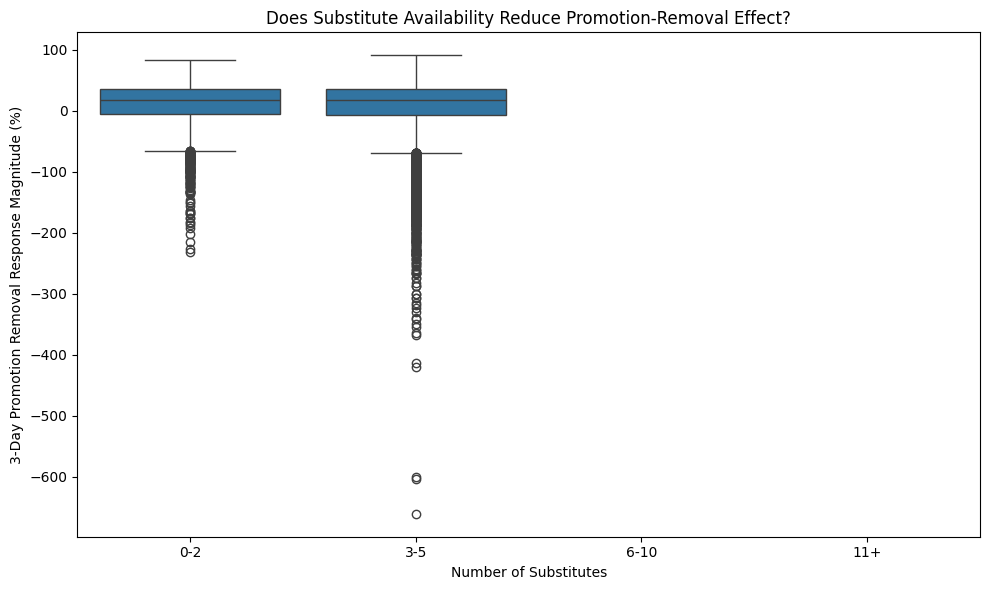

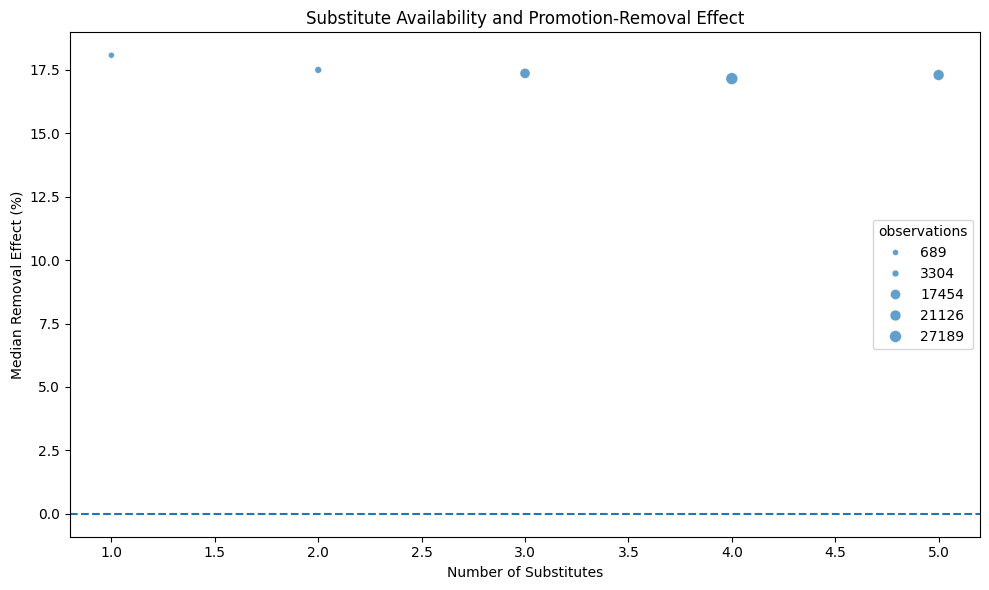


FINAL REGRESSION SUMMARY
          Specification  Key_Coefficient  P_Value
     3-day removal only        -0.058750 0.692157
     7-day removal only        -0.047711 0.637453
3-day interaction model         0.189722 0.379283
7-day interaction model         0.022873 0.867153


ANALYSIS COMPLETE


In [23]:
# ================================================================
# FMCG BEHAVIORAL ECONOMICS
# HYPOTHESIS:
#
# "Does availability of substitutes reduce the promotion-removal
# effect?"
#
# ================================================================
#
# H1:
#
# More substitutes available for a SKU
# -> smaller demand loss after promotion removal.
#
# KEY EXPECTATION:
#
# beta(Removal × Number_of_Substitutes) < 0
#
# ================================================================


# ================================================================
# 1. IMPORTS
# ================================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

from scipy import stats


# ================================================================
# 2. USER SETTINGS
# ================================================================

# ------------------------------------------------
# CHANGE THIS ONLY IF YOUR COLUMN HAS A DIFFERENT NAME
# ------------------------------------------------

SUBSTITUTE_GROUP_COL = "substitute_group"


# ------------------------------------------------
# If you already have a column containing the number
# of substitutes, put its name here.
#
# Otherwise keep None and the code will calculate it
# from substitute_group.
# ------------------------------------------------

SUBSTITUTE_COUNT_COL = None


# ================================================================
# 3. COPY DATA
# ================================================================

data = df.copy()


# ================================================================
# 4. CHECK REQUIRED COLUMNS
# ================================================================

required = [
    "sku_id",
    "store_id",
    "date",
    "units_sold",
    "discount_pct"
]

missing = [
    c for c in required
    if c not in data.columns
]

if missing:

    raise ValueError(
        f"Missing required columns: {missing}"
    )


# ================================================================
# 5. CLEAN BASIC VARIABLES
# ================================================================

data["date"] = pd.to_datetime(
    data["date"],
    errors="coerce"
)

data["units_sold"] = pd.to_numeric(
    data["units_sold"],
    errors="coerce"
)

data["discount_pct"] = pd.to_numeric(
    data["discount_pct"],
    errors="coerce"
)


data = data[
    data["date"].notna() &
    data["units_sold"].notna() &
    data["discount_pct"].notna()
].copy()


data = data[
    data["units_sold"] >= 0
].copy()


data = data[
    data["discount_pct"] >= 0
].copy()


# ================================================================
# 6. STANDARDIZE DISCOUNT
#
# 20  -> 0.20
# 0.20 -> 0.20
# ================================================================

if data["discount_pct"].max() > 1:

    data["discount"] = (
        data["discount_pct"] / 100
    )

else:

    data["discount"] = (
        data["discount_pct"]
    )


data = data[
    data["discount"] <= 1
].copy()


# ================================================================
# 7. SORT PANEL
# ================================================================

group_cols = [
    "sku_id",
    "store_id"
]

data = data.sort_values(
    group_cols + ["date"]
).reset_index(drop=True)


# ================================================================
# 8. DATA QUALITY
# ================================================================

duplicates = data.duplicated(
    subset=[
        "sku_id",
        "store_id",
        "date"
    ]
).sum()


print("=" * 80)
print("DATA QUALITY")
print("=" * 80)

print(
    "Rows:",
    len(data)
)

print(
    "SKUs:",
    data["sku_id"].nunique()
)

print(
    "Stores:",
    data["store_id"].nunique()
)

print(
    "Duplicate SKU-store-date rows:",
    duplicates
)


if duplicates > 0:

    raise ValueError(
        "Duplicate SKU × Store × Date observations found."
    )


# ================================================================
# 9. SUBSTITUTE COUNT
# ================================================================
#
# CASE 1:
# You already have substitute count
#
# CASE 2:
# You have substitute_group
#
# Number of substitutes =
#
# number of SKUs in the same store and substitute group - 1
#
# We subtract one because the focal SKU itself is not a substitute.
# ================================================================


if (
    SUBSTITUTE_COUNT_COL is not None
    and
    SUBSTITUTE_COUNT_COL in data.columns
):

    print(
        "\nUsing existing substitute-count column:"
    )

    print(
        SUBSTITUTE_COUNT_COL
    )

    data["num_substitutes"] = pd.to_numeric(
        data[SUBSTITUTE_COUNT_COL],
        errors="coerce"
    )


elif SUBSTITUTE_GROUP_COL in data.columns:

    print(
        "\nCalculating substitute count from:"
    )

    print(
        SUBSTITUTE_GROUP_COL
    )


    # Number of unique SKUs within each
    # store × substitute group

    substitute_counts = (
        data
        .groupby(
            [
                "store_id",
                SUBSTITUTE_GROUP_COL
            ]
        )["sku_id"]
        .nunique()
        .reset_index(
            name="group_sku_count"
        )
    )


    data = data.merge(
        substitute_counts,
        on=[
            "store_id",
            SUBSTITUTE_GROUP_COL
        ],
        how="left"
    )


    data["num_substitutes"] = (
        data["group_sku_count"] - 1
    )


else:

    raise ValueError(
        f"""
Could not find substitute information.

Your dataframe does not contain:
{SUBSTITUTE_COUNT_COL}

or:
{SUBSTITUTE_GROUP_COL}

Please change SUBSTITUTE_GROUP_COL at the
top of the code to the actual substitute-group
column in your dataset.
"""
    )


# ================================================================
# 10. SUBSTITUTE COUNT CHECK
# ================================================================

data["num_substitutes"] = pd.to_numeric(
    data["num_substitutes"],
    errors="coerce"
)


data["num_substitutes"] = (
    data["num_substitutes"]
    .clip(lower=0)
)


print("\n" + "=" * 80)
print("SUBSTITUTE AVAILABILITY")
print("=" * 80)

print(
    data["num_substitutes"].describe()
)

print(
    "\nNumber of unique substitute counts:"
)

print(
    sorted(
        data["num_substitutes"]
        .dropna()
        .unique()
    )
)


# ================================================================
# 11. CREATE SUBSTITUTE INTENSITY VARIABLES
# ================================================================
#
# We use:
#
# 1. Raw number of substitutes
# 2. Log(number of substitutes + 1)
#
# Log specification is useful because going from:
#
# 1 -> 2 substitutes
#
# may matter more than:
#
# 20 -> 21 substitutes.
# ================================================================

data["log_substitutes"] = np.log1p(
    data["num_substitutes"]
)


# Standardized version
data["substitute_z"] = (
    (
        data["num_substitutes"]
        -
        data["num_substitutes"].mean()
    )
    /
    data["num_substitutes"].std()
)


# ================================================================
# 12. PREVIOUS DISCOUNT
# ================================================================

data["previous_discount"] = (
    data
    .groupby(group_cols)["discount"]
    .shift(1)
)


data["previous_date"] = (
    data
    .groupby(group_cols)["date"]
    .shift(1)
)


data["days_gap"] = (
    data["date"]
    -
    data["previous_date"]
).dt.days


# ================================================================
# 13. PROMOTION INTRODUCTION
#
# 0 -> positive discount
# ================================================================

data["promotion_introduction"] = (
    (data["days_gap"] == 1)
    &
    (data["previous_discount"] == 0)
    &
    (data["discount"] > 0)
)


# ================================================================
# 14. PROMOTION REMOVAL
#
# positive discount -> 0
# ================================================================

data["promotion_removal"] = (
    (data["days_gap"] == 1)
    &
    (data["previous_discount"] > 0)
    &
    (data["discount"] == 0)
)


# ================================================================
# 15. EVENT DATAFRAME
# ================================================================

events = data[
    data["promotion_introduction"]
    |
    data["promotion_removal"]
].copy()


events["event_type"] = np.where(
    events["promotion_removal"],
    "Removal",
    "Introduction"
)


events["removal"] = (
    events["promotion_removal"]
    .astype(int)
)


# ================================================================
# 16. DISCOUNT INTENSITY
#
# For introduction:
# current discount
#
# For removal:
# previous promotional discount
#
# This gives the intensity of the promotion associated
# with the event.
# ================================================================

events["promotion_intensity"] = np.where(

    events["event_type"] == "Introduction",

    events["discount"],

    events["previous_discount"]

)


events["promotion_intensity_pct"] = (
    events["promotion_intensity"] * 100
)


# ================================================================
# 17. CREATE EXACT CALENDAR-DAY SALES
# ================================================================
#
# We need:
#
# t-1 ... t-7
# t+1 ... t+7
#
# IMPORTANT:
# We use exact calendar dates, not shift().
#
# ================================================================

sales = data[
    [
        "sku_id",
        "store_id",
        "date",
        "units_sold"
    ]
].copy()


events = events.reset_index(
    drop=True
)

events["event_id"] = (
    np.arange(len(events))
)


# ================================================================
# 18. ADD PRE/POST SALES
# ================================================================

for k in range(1, 8):

    # ------------------------------------------------------------
    # PRE
    # ------------------------------------------------------------

    lookup = sales.rename(
        columns={
            "date": "lookup_date",
            "units_sold":
                f"pre_{k}"
        }
    )


    temp = events[
        [
            "event_id",
            "sku_id",
            "store_id",
            "date"
        ]
    ].copy()


    temp["lookup_date"] = (
        temp["date"]
        -
        pd.Timedelta(days=k)
    )


    temp = temp.merge(
        lookup,
        on=[
            "sku_id",
            "store_id",
            "lookup_date"
        ],
        how="left"
    )


    events = events.merge(
        temp[
            [
                "event_id",
                f"pre_{k}"
            ]
        ],
        on="event_id",
        how="left"
    )


    # ------------------------------------------------------------
    # POST
    # ------------------------------------------------------------

    lookup = sales.rename(
        columns={
            "date": "lookup_date",
            "units_sold":
                f"post_{k}"
        }
    )


    temp = events[
        [
            "event_id",
            "sku_id",
            "store_id",
            "date"
        ]
    ].copy()


    temp["lookup_date"] = (
        temp["date"]
        +
        pd.Timedelta(days=k)
    )


    temp = temp.merge(
        lookup,
        on=[
            "sku_id",
            "store_id",
            "lookup_date"
        ],
        how="left"
    )


    events = events.merge(
        temp[
            [
                "event_id",
                f"post_{k}"
            ]
        ],
        on="event_id",
        how="left"
    )


# ================================================================
# 19. CALCULATE 1-DAY / 3-DAY / 7-DAY RESPONSE
# ================================================================

for window in [1, 3, 7]:

    pre_cols = [
        f"pre_{k}"
        for k in range(1, window + 1)
    ]

    post_cols = [
        f"post_{k}"
        for k in range(1, window + 1)
    ]


    events[
        f"pre_mean_{window}d"
    ] = events[
        pre_cols
    ].mean(
        axis=1,
        skipna=False
    )


    events[
        f"post_mean_{window}d"
    ] = events[
        post_cols
    ].mean(
        axis=1,
        skipna=False
    )


    events[
        f"response_{window}d"
    ] = np.where(

        events[
            f"pre_mean_{window}d"
        ] > 0,

        (
            (
                events[
                    f"post_mean_{window}d"
                ]
                -
                events[
                    f"pre_mean_{window}d"
                ]
            )
            /
            events[
                f"pre_mean_{window}d"
            ]
        )
        *
        100,

        np.nan
    )


# ================================================================
# 20. RESPONSE MAGNITUDE
#
# Introduction:
# positive response = positive magnitude
#
# Removal:
# negative response becomes positive magnitude
#
# ================================================================

for window in [1, 3, 7]:

    events[
        f"response_magnitude_{window}d"
    ] = np.where(

        events["removal"] == 1,

        -events[
            f"response_{window}d"
        ],

        events[
            f"response_{window}d"
        ]

    )


# ================================================================
# 21. CHECK EVENT SAMPLE
# ================================================================

print("\n" + "=" * 80)
print("EVENT SAMPLE")
print("=" * 80)

print(
    events["event_type"].value_counts()
)


for window in [1, 3, 7]:

    print(
        f"\nValid {window}-day responses:",
        events[
            f"response_{window}d"
        ].notna().sum()
    )


# ================================================================
# 22. CALENDAR VARIABLES
#
# Rather than deleting holidays/seasonality,
# we control for common calendar effects.
# ================================================================

events["year"] = (
    events["date"].dt.year
)

events["month"] = (
    events["date"].dt.month
)

events["day_of_week"] = (
    events["date"].dt.dayofweek
)

events["week_of_year"] = (
    events["date"].dt.isocalendar().week
    .astype(int)
)


# ================================================================
# 23. DATE FIXED EFFECT
#
# Every exact date gets a categorical identifier.
#
# This absorbs:
#
# - Diwali
# - Holi
# - Christmas
# - New Year
# - general demand shocks
# - common weather shocks
# - common calendar effects
#
# shared across stores/SKUs on that date.
# ================================================================

events["date_fe"] = (
    events["date"].astype(str)
)


# ================================================================
# 24. STANDARDIZE CONTINUOUS VARIABLES
#
# This makes coefficients easier to compare.
# ================================================================

events["discount_z"] = (
    (
        events["promotion_intensity"]
        -
        events["promotion_intensity"].mean()
    )
    /
    events["promotion_intensity"].std()
)


events["substitute_z"] = (
    (
        events["num_substitutes"]
        -
        events["num_substitutes"].mean()
    )
    /
    events["num_substitutes"].std()
)


# ================================================================
# 25. INTERACTION
#
# Removal × Substitute availability
#
# This is our KEY VARIABLE.
# ================================================================

events["removal_x_substitute"] = (
    events["removal"]
    *
    events["substitute_z"]
)


# ================================================================
# 26. PREPARE 3-DAY AND 7-DAY SAMPLES
# ================================================================

analysis_3d = events[
    events["response_3d"].notna()
].copy()


analysis_7d = events[
    events["response_7d"].notna()
].copy()


print("\n" + "=" * 80)
print("REGRESSION SAMPLES")
print("=" * 80)

print(
    "3-day:",
    len(analysis_3d)
)

print(
    "7-day:",
    len(analysis_7d)
)


# ================================================================
# 27. REGRESSION 1
#
# 3-DAY RESPONSE
#
# Model:
#
# Response =
#
# Removal
# + Substitute availability
# + Removal × Substitute
# + Discount intensity
# + SKU FE
# + Store FE
# + Calendar controls
#
# ================================================================

print("\n")
print("=" * 80)
print("REGRESSION 1 — 3-DAY RESPONSE")
print("=" * 80)


formula_3d = """

response_3d

~ removal

+ substitute_z

+ removal_x_substitute

+ discount_z

+ C(sku_id)

+ C(store_id)

+ C(day_of_week)

+ C(month)

+ C(year)

"""


model_3d = smf.ols(
    formula=formula_3d,
    data=analysis_3d
).fit(
    cov_type="HC3"
)


print(
    model_3d.summary()
)


# ================================================================
# 28. EXTRACT KEY COEFFICIENTS
# ================================================================

print("\n" + "=" * 80)
print("KEY 3-DAY COEFFICIENTS")
print("=" * 80)


print(
    model_3d.params[
        [
            "removal",
            "substitute_z",
            "removal_x_substitute",
            "discount_z"
        ]
    ]
)


print("\nP-VALUES")


print(
    model_3d.pvalues[
        [
            "removal",
            "substitute_z",
            "removal_x_substitute",
            "discount_z"
        ]
    ]
)


# ================================================================
# 29. REGRESSION 2
#
# 7-DAY RESPONSE
# ================================================================

print("\n")
print("=" * 80)
print("REGRESSION 2 — 7-DAY RESPONSE")
print("=" * 80)


formula_7d = """

response_7d

~ removal

+ substitute_z

+ removal_x_substitute

+ discount_z

+ C(sku_id)

+ C(store_id)

+ C(day_of_week)

+ C(month)

+ C(year)

"""


model_7d = smf.ols(
    formula=formula_7d,
    data=analysis_7d
).fit(
    cov_type="HC3"
)


print(
    model_7d.summary()
)


# ================================================================
# 30. KEY 7-DAY COEFFICIENTS
# ================================================================

print("\n" + "=" * 80)
print("KEY 7-DAY COEFFICIENTS")
print("=" * 80)


print(
    model_7d.params[
        [
            "removal",
            "substitute_z",
            "removal_x_substitute",
            "discount_z"
        ]
    ]
)


print("\nP-VALUES")


print(
    model_7d.pvalues[
        [
            "removal",
            "substitute_z",
            "removal_x_substitute",
            "discount_z"
        ]
    ]
)


# ================================================================
# 31. DIRECT REMOVAL-ONLY REGRESSION
#
# This is the cleanest test of the specific hypothesis:
#
# "Does substitute availability reduce the removal effect?"
#
# ================================================================

removal_3d = analysis_3d[
    analysis_3d["removal"] == 1
].copy()


removal_7d = analysis_7d[
    analysis_7d["removal"] == 1
].copy()


# ------------------------------------------------
# 3-DAY REMOVAL-ONLY
# ------------------------------------------------

print("\n")
print("=" * 80)
print("REGRESSION 3 — REMOVAL ONLY — 3 DAYS")
print("=" * 80)


removal_model_3d = smf.ols(

    formula="""

    response_magnitude_3d

    ~ substitute_z

    + discount_z

    + C(sku_id)

    + C(store_id)

    + C(day_of_week)

    + C(month)

    + C(year)

    """,

    data=removal_3d

).fit(
    cov_type="HC3"
)


print(
    removal_model_3d.summary()
)


# ================================================================
# 32. 7-DAY REMOVAL-ONLY
# ================================================================

print("\n")
print("=" * 80)
print("REGRESSION 4 — REMOVAL ONLY — 7 DAYS")
print("=" * 80)


removal_model_7d = smf.ols(

    formula="""

    response_magnitude_7d

    ~ substitute_z

    + discount_z

    + C(sku_id)

    + C(store_id)

    + C(day_of_week)

    + C(month)

    + C(year)

    """,

    data=removal_7d

).fit(
    cov_type="HC3"
)


print(
    removal_model_7d.summary()
)


# ================================================================
# 33. KEY REMOVAL-ONLY COEFFICIENTS
# ================================================================

print("\n" + "=" * 80)
print("REMOVAL-ONLY RESULTS")
print("=" * 80)


print(
    "3-day substitute coefficient:",
    removal_model_3d.params[
        "substitute_z"
    ]
)

print(
    "3-day p-value:",
    removal_model_3d.pvalues[
        "substitute_z"
    ]
)


print(
    "\n7-day substitute coefficient:",
    removal_model_7d.params[
        "substitute_z"
    ]
)

print(
    "7-day p-value:",
    removal_model_7d.pvalues[
        "substitute_z"
    ]
)


# ================================================================
# 34. INTERPRETATION OF KEY COEFFICIENT
# ================================================================
#
# substitute_z is standardized.
#
# Therefore:
#
# coefficient = change in percentage-point sales response
# associated with a 1 standard deviation increase in
# substitute availability.
#
# For removal-only regression:
#
# NEGATIVE coefficient = supports H1.
#
# ================================================================

coef_3d = removal_model_3d.params[
    "substitute_z"
]

p_3d = removal_model_3d.pvalues[
    "substitute_z"
]


coef_7d = removal_model_7d.params[
    "substitute_z"
]

p_7d = removal_model_7d.pvalues[
    "substitute_z"
]


print("\n" + "=" * 80)
print("HYPOTHESIS INTERPRETATION")
print("=" * 80)


print(
    f"""
3-DAY:

A one-standard-deviation increase in substitute
availability is associated with a
{coef_3d:.3f} percentage-point change in the
promotion-removal response magnitude.

p-value = {p_3d:.6g}
"""
)


print(
    f"""
7-DAY:

A one-standard-deviation increase in substitute
availability is associated with a
{coef_7d:.3f} percentage-point change in the
promotion-removal response magnitude.

p-value = {p_7d:.6g}
"""
)


# ================================================================
# 35. HYPOTHESIS VERDICT
# ================================================================

if (
    coef_3d < 0
    and
    p_3d < 0.05
    and
    coef_7d < 0
    and
    p_7d < 0.05
):

    print(
        """
========================================================
H1 SUPPORTED
========================================================

Greater substitute availability significantly reduces
the magnitude of the promotion-removal effect in BOTH
the 3-day and 7-day analyses.
"""
    )


elif (
    coef_3d < 0
    and
    p_3d < 0.05
):

    print(
        """
========================================================
PARTIAL SUPPORT
========================================================

The hypothesis is supported in the 3-day specification,
but not consistently across both windows.
"""
    )


elif (
    coef_7d < 0
    and
    p_7d < 0.05
):

    print(
        """
========================================================
PARTIAL SUPPORT
========================================================

The hypothesis is supported in the 7-day specification,
but not consistently across both windows.
"""
    )


else:

    print(
        """
========================================================
H1 NOT SUPPORTED
========================================================

The regression does not provide statistically significant
evidence that substitute availability reduces the
promotion-removal effect.
"""
    )


# ================================================================
# 36. NONLINEAR SUBSTITUTE SPECIFICATION
#
# Perhaps substitutes do not have a linear effect.
#
# We test:
#
# log(1 + number of substitutes)
# ================================================================

removal_3d["log_substitutes"] = np.log1p(
    removal_3d["num_substitutes"]
)


removal_7d["log_substitutes"] = np.log1p(
    removal_7d["num_substitutes"]
)


print("\n" + "=" * 80)
print("NONLINEAR SUBSTITUTE SPECIFICATION")
print("=" * 80)


log_model_3d = smf.ols(

    formula="""

    response_magnitude_3d

    ~ log_substitutes

    + discount_z

    + C(sku_id)

    + C(store_id)

    + C(day_of_week)

    + C(month)

    + C(year)

    """,

    data=removal_3d

).fit(
    cov_type="HC3"
)


print(
    "3-day log substitute coefficient:",
    log_model_3d.params[
        "log_substitutes"
    ]
)

print(
    "p-value:",
    log_model_3d.pvalues[
        "log_substitutes"
    ]
)


# ================================================================
# 37. SUBSTITUTE COUNT CATEGORIES
#
# To visualize the relationship:
#
# 0-2
# 3-5
# 6-10
# 11+
# ================================================================

def substitute_bucket(x):

    if x <= 2:
        return "0-2"

    elif x <= 5:
        return "3-5"

    elif x <= 10:
        return "6-10"

    else:
        return "11+"


removal_3d["substitute_bucket"] = (
    removal_3d[
        "num_substitutes"
    ].apply(substitute_bucket)
)


bucket_order = [
    "0-2",
    "3-5",
    "6-10",
    "11+"
]


bucket_summary = (
    removal_3d
    .groupby(
        "substitute_bucket",
        observed=True
    )
    .agg(
        observations=(
            "response_magnitude_3d",
            "count"
        ),

        mean_removal_effect=(
            "response_magnitude_3d",
            "mean"
        ),

        median_removal_effect=(
            "response_magnitude_3d",
            "median"
        )
    )
    .reindex(bucket_order)
    .reset_index()
)


print("\n" + "=" * 80)
print("REMOVAL EFFECT BY SUBSTITUTE AVAILABILITY")
print("=" * 80)

print(
    bucket_summary.to_string(
        index=False
    )
)


# ================================================================
# 38. PLOT SUBSTITUTE AVAILABILITY VS REMOVAL EFFECT
# ================================================================

plt.figure(
    figsize=(10, 6)
)

sns.boxplot(
    data=removal_3d,
    x="substitute_bucket",
    y="response_magnitude_3d",
    order=bucket_order
)

plt.xlabel(
    "Number of Substitutes"
)

plt.ylabel(
    "3-Day Promotion Removal Response Magnitude (%)"
)

plt.title(
    "Does Substitute Availability Reduce Promotion-Removal Effect?"
)

plt.tight_layout()

plt.show()


# ================================================================
# 39. SCATTER / BINNED RELATIONSHIP
# ================================================================

binned = (
    removal_3d
    .groupby(
        "num_substitutes"
    )
    .agg(
        median_effect=(
            "response_magnitude_3d",
            "median"
        ),

        mean_effect=(
            "response_magnitude_3d",
            "mean"
        ),

        observations=(
            "response_magnitude_3d",
            "count"
        )
    )
    .reset_index()
)


binned = binned[
    binned["observations"] >= 30
]


plt.figure(
    figsize=(10, 6)
)

sns.scatterplot(
    data=binned,
    x="num_substitutes",
    y="median_effect",
    size="observations",
    alpha=0.7
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Number of Substitutes"
)

plt.ylabel(
    "Median Removal Effect (%)"
)

plt.title(
    "Substitute Availability and Promotion-Removal Effect"
)

plt.tight_layout()

plt.show()


# ================================================================
# 40. SAVE RESULTS
# ================================================================

events.to_csv(
    "substitution_hypothesis_all_events.csv",
    index=False
)


analysis_3d.to_csv(
    "substitution_hypothesis_3day_events.csv",
    index=False
)


analysis_7d.to_csv(
    "substitution_hypothesis_7day_events.csv",
    index=False
)


bucket_summary.to_csv(
    "substitution_hypothesis_buckets.csv",
    index=False
)


# ================================================================
# 41. FINAL SUMMARY TABLE
# ================================================================

summary = pd.DataFrame({

    "Specification": [

        "3-day removal only",
        "7-day removal only",
        "3-day interaction model",
        "7-day interaction model"

    ],

    "Key_Coefficient": [

        coef_3d,
        coef_7d,

        model_3d.params[
            "removal_x_substitute"
        ],

        model_7d.params[
            "removal_x_substitute"
        ]

    ],

    "P_Value": [

        p_3d,
        p_7d,

        model_3d.pvalues[
            "removal_x_substitute"
        ],

        model_7d.pvalues[
            "removal_x_substitute"
        ]

    ]

})


print("\n" + "=" * 80)
print("FINAL REGRESSION SUMMARY")
print("=" * 80)

print(
    summary.to_string(
        index=False
    )
)


summary.to_csv(
    "substitution_hypothesis_regression_summary.csv",
    index=False
)


print("\n")
print("=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)

In [24]:
print("=" * 80)
print("ALL COLUMNS IN DATASET")
print("=" * 80)

for i, col in enumerate(df.columns):
    print(i, repr(col))


print("\n" + "=" * 80)
print("POSSIBLE SUBSTITUTE / COMPETITION COLUMNS")
print("=" * 80)

keywords = [
    "sub",
    "substitute",
    "compet",
    "group",
    "grade",
    "rank",
    "comp"
]

possible = [
    col for col in df.columns
    if any(
        keyword in str(col).lower()
        for keyword in keywords
    )
]

for col in possible:
    print(
        repr(col),
        " | dtype = ",
        df[col].dtype,
        " | unique = ",
        df[col].nunique()
    )


print("\n" + "=" * 80)
print("FIRST 10 ROWS OF POSSIBLE COLUMNS")
print("=" * 80)

if possible:
    display(
        df[possible].head(10)
    )
else:
    print(
        "No obvious substitute/competition column found."
    )

ALL COLUMNS IN DATASET
0 'date'
1 'year'
2 'month'
3 'day'
4 'weekofyear'
5 'weekday'
6 'is_weekend'
7 'is_holiday'
8 'store_id'
9 'country'
10 'city'
11 'sku_id'
12 'category'
13 'subcategory'
14 'brand'
15 'units_sold'
16 'list_price'
17 'discount_pct'
18 'promo_flag'
19 'gross_sales'
20 'net_sales'
21 'stock_on_hand'
22 'stock_out_flag'
23 'purchase_cost'
24 'margin_pct'
25 'substitute_group'

POSSIBLE SUBSTITUTE / COMPETITION COLUMNS
'subcategory'  | dtype =  object  | unique =  17
'substitute_group'  | dtype =  int64  | unique =  17

FIRST 10 ROWS OF POSSIBLE COLUMNS


,subcategory,substitute_group
0,Shampoo,11
1,Shampoo,11
2,Shampoo,11
3,Shampoo,11
4,Shampoo,11
5,Shampoo,11
6,Shampoo,11
7,Shampoo,11
8,Shampoo,11
9,Shampoo,11


In [1]:
# ================================================================
# ACTUAL COMPETITIVE SUBSTITUTION ANALYSIS
#
# H1:
# When a promotion is removed from SKU A, sales of other SKUs
# in the same substitute_group increase.
#
# H2:
# The demand lost by A is partially captured by its substitutes.
#
# Windows:
#   3 days
#   7 days
#
# Controls:
#   promotion intensity
#   holidays
#   stock-outs
#   SKU
#   store
#   calendar
#
# ================================================================

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt


# ================================================================
# 1. COPY AND CLEAN
# ================================================================

data = df.copy()

data["date"] = pd.to_datetime(data["date"])

for col in [
    "units_sold",
    "list_price",
    "discount_pct",
    "promo_flag",
    "is_holiday",
    "stock_out_flag",
    "substitute_group"
]:
    data[col] = pd.to_numeric(
        data[col],
        errors="coerce"
    )


data = data.sort_values(
    [
        "store_id",
        "sku_id",
        "date"
    ]
).reset_index(drop=True)


# ================================================================
# 2. CHECK PANEL
# ================================================================

print("=" * 80)
print("DATA")
print("=" * 80)

print("Rows:", len(data))
print("SKUs:", data["sku_id"].nunique())
print("Stores:", data["store_id"].nunique())
print(
    "Substitute groups:",
    data["substitute_group"].nunique()
)

print(
    "Duplicate SKU-store-date:",
    data.duplicated(
        [
            "store_id",
            "sku_id",
            "date"
        ]
    ).sum()
)


# ================================================================
# 3. DISCOUNT STANDARDIZATION
# ================================================================

if data["discount_pct"].max() > 1:

    data["discount"] = (
        data["discount_pct"] / 100
    )

else:

    data["discount"] = (
        data["discount_pct"]
    )


# ================================================================
# 4. PREVIOUS DAY DISCOUNT
# ================================================================

data["previous_discount"] = (

    data
    .groupby(
        [
            "store_id",
            "sku_id"
        ]
    )["discount"]
    .shift(1)

)


data["previous_date"] = (

    data
    .groupby(
        [
            "store_id",
            "sku_id"
        ]
    )["date"].shift(1)

)


data["days_gap"] = (

    data["date"]
    -
    data["previous_date"]

).dt.days


# ================================================================
# 5. PROMOTION REMOVAL
# ================================================================
#
# Previous day:
# discount > 0
#
# Current day:
# discount = 0
#
# Consecutive observations.
# ================================================================

data["promotion_removal"] = (

    (data["days_gap"] == 1)
    &
    (data["previous_discount"] > 0)
    &
    (data["discount"] == 0)

)


removals = data[
    data["promotion_removal"]
].copy()


removals = removals.reset_index(
    drop=True
)


removals["event_id"] = np.arange(
    len(removals)
)


# Promotion intensity
removals["promotion_intensity"] = (
    removals["previous_discount"]
)


removals["promotion_intensity_pct"] = (
    removals["promotion_intensity"] * 100
)


print("\n" + "=" * 80)
print("PROMOTION REMOVALS")
print("=" * 80)

print(
    "Removal events:",
    len(removals)
)


# ================================================================
# 6. CREATE SALES LOOKUP
# ================================================================

sales = data[
    [
        "store_id",
        "sku_id",
        "date",
        "units_sold",
        "stock_out_flag"
    ]
].copy()


# ================================================================
# 7. FUNCTION:
#    GET PRE/POST RESPONSE FOR ANY SKU
# ================================================================

def calculate_response(
    events,
    sales,
    sku_column,
    window
):

    result = events[
        [
            "event_id",
            "store_id",
            sku_column,
            "date"
        ]
    ].copy()


    for k in range(1, window + 1):

        # --------------------------------------------------------
        # PRE
        # --------------------------------------------------------

        lookup = sales.rename(
            columns={
                "date": "lookup_date",
                "sku_id": sku_column,
                "units_sold":
                    f"pre_units_{k}",
                "stock_out_flag":
                    f"pre_stockout_{k}"
            }
        )


        target = result[
            [
                "event_id",
                "store_id",
                sku_column,
                "date"
            ]
        ].copy()


        target["lookup_date"] = (
            target["date"]
            -
            pd.Timedelta(days=k)
        )


        target = target.merge(
            lookup,
            on=[
                "store_id",
                sku_column,
                "lookup_date"
            ],
            how="left"
        )


        result = result.merge(
            target[
                [
                    "event_id",
                    f"pre_units_{k}",
                    f"pre_stockout_{k}"
                ]
            ],
            on="event_id",
            how="left"
        )


        # --------------------------------------------------------
        # POST
        # --------------------------------------------------------

        lookup = sales.rename(
            columns={
                "date": "lookup_date",
                "sku_id": sku_column,
                "units_sold":
                    f"post_units_{k}",
                "stock_out_flag":
                    f"post_stockout_{k}"
            }
        )


        target = result[
            [
                "event_id",
                "store_id",
                sku_column,
                "date"
            ]
        ].copy()


        target["lookup_date"] = (
            target["date"]
            +
            pd.Timedelta(days=k)
        )


        target = target.merge(
            lookup,
            on=[
                "store_id",
                sku_column,
                "lookup_date"
            ],
            how="left"
        )


        result = result.merge(
            target[
                [
                    "event_id",
                    f"post_units_{k}",
                    f"post_stockout_{k}"
                ]
            ],
            on="event_id",
            how="left"
        )


    # ------------------------------------------------------------
    # WINDOW AVERAGES
    # ------------------------------------------------------------

    pre_cols = [
        f"pre_units_{k}"
        for k in range(1, window + 1)
    ]

    post_cols = [
        f"post_units_{k}"
        for k in range(1, window + 1)
    ]


    result[
        f"pre_units_{window}d"
    ] = result[
        pre_cols
    ].mean(
        axis=1,
        skipna=False
    )


    result[
        f"post_units_{window}d"
    ] = result[
        post_cols
    ].mean(
        axis=1,
        skipna=False
    )


    # Absolute unit change
    result[
        f"unit_change_{window}d"
    ] = (

        result[
            f"post_units_{window}d"
        ]

        -

        result[
            f"pre_units_{window}d"
        ]

    )


    # Percentage change
    result[
        f"response_{window}d"
    ] = np.where(

        result[
            f"pre_units_{window}d"
        ] > 0,

        (
            (
                result[
                    f"post_units_{window}d"
                ]
                -
                result[
                    f"pre_units_{window}d"
                ]
            )
            /
            result[
                f"pre_units_{window}d"
            ]
        ) * 100,

        np.nan

    )


    return result


# ================================================================
# 8. FOCAL SKU RESPONSE
# ================================================================

focal_3d = calculate_response(
    removals,
    sales,
    "sku_id",
    3
)


focal_7d = calculate_response(
    removals,
    sales,
    "sku_id",
    7
)


# Keep only useful columns

focal_3d = focal_3d[
    [
        "event_id",
        "pre_units_3d",
        "post_units_3d",
        "unit_change_3d",
        "response_3d"
    ]
]


focal_7d = focal_7d[
    [
        "event_id",
        "pre_units_7d",
        "post_units_7d",
        "unit_change_7d",
        "response_7d"
    ]
]


removals = removals.merge(
    focal_3d,
    on="event_id",
    how="left"
)


removals = removals.merge(
    focal_7d,
    on="event_id",
    how="left"
)


# ================================================================
# 9. FOCAL SKU INFORMATION
# ================================================================

focal_information = removals[
    [
        "event_id",
        "store_id",
        "sku_id",
        "date",
        "substitute_group",
        "promotion_intensity",
        "promotion_intensity_pct",
        "response_3d",
        "response_7d",
        "unit_change_3d",
        "unit_change_7d"
    ]
].copy()


focal_information = focal_information.rename(
    columns={
        "sku_id": "focal_sku"
    }
)


# ================================================================
# 10. CREATE ALL COMPETITOR PAIRS
# ================================================================
#
# Same store
# Same substitute group
# Different SKU
#
# ================================================================

sku_group_map = (

    data[
        [
            "store_id",
            "sku_id",
            "substitute_group"
        ]
    ]

    .drop_duplicates()

)


focal_map = sku_group_map.rename(
    columns={
        "sku_id":
            "focal_sku"
    }
)


competitor_map = sku_group_map.rename(
    columns={
        "sku_id":
            "competitor_sku"
    }
)


pairs = focal_map.merge(
    competitor_map,
    on=[
        "store_id",
        "substitute_group"
    ],
    how="inner"
)


pairs = pairs[
    pairs["focal_sku"]
    !=
    pairs["competitor_sku"]
].copy()


print("\n" + "=" * 80)
print("COMPETITIVE PAIRS")
print("=" * 80)

print(
    "Focal → competitor pairs:",
    len(pairs)
)


# ================================================================
# 11. CREATE COMPETITOR EVENT DATASET
# ================================================================

competitor_events = focal_information.merge(
    pairs,
    on=[
        "store_id",
        "focal_sku"
    ],
    how="inner"
)


print(
    "Competitor-event rows:",
    len(competitor_events)
)


print(
    "Unique removal events:",
    competitor_events[
        "event_id"
    ].nunique()
)


print(
    "Unique competitor SKUs:",
    competitor_events[
        "competitor_sku"
    ].nunique()
)


# ================================================================
# 12. COMPETITOR SALES RESPONSE
# ================================================================

competitor_3d = calculate_response(
    competitor_events,
    sales,
    "competitor_sku",
    3
)


competitor_7d = calculate_response(
    competitor_events,
    sales,
    "competitor_sku",
    7
)


competitor_3d = competitor_3d[
    [
        "event_id",
        "pre_units_3d",
        "post_units_3d",
        "unit_change_3d",
        "response_3d"
    ]
].rename(
    columns={
        "pre_units_3d":
            "competitor_pre_units_3d",

        "post_units_3d":
            "competitor_post_units_3d",

        "unit_change_3d":
            "competitor_unit_change_3d",

        "response_3d":
            "competitor_response_3d"
    }
)


competitor_7d = competitor_7d[
    [
        "event_id",
        "pre_units_7d",
        "post_units_7d",
        "unit_change_7d",
        "response_7d"
    ]
].rename(
    columns={
        "pre_units_7d":
            "competitor_pre_units_7d",

        "post_units_7d":
            "competitor_post_units_7d",

        "unit_change_7d":
            "competitor_unit_change_7d",

        "response_7d":
            "competitor_response_7d"
    }
)


competitor_events = competitor_events.merge(
    competitor_3d,
    on="event_id",
    how="left"
)


competitor_events = competitor_events.merge(
    competitor_7d,
    on="event_id",
    how="left"
)


# ================================================================
# 13. REMOVE EVENTS WHERE COMPETITOR WAS OUT OF STOCK
#
# We want to measure actual substitution opportunity.
#
# If competitor is repeatedly out of stock during the
# post-event window, it cannot realistically capture demand.
# ================================================================

for window in [3, 7]:

    post_stock_cols = [
        f"post_stockout_{k}"
        for k in range(1, window + 1)
        if f"post_stockout_{k}" in
        competitor_events.columns
    ]

    # These columns aren't retained by the current function.
    # We therefore use the original stock data below instead.


# ================================================================
# 14. CREATE EVENT-DATE HOLIDAY CONTROL
# ================================================================

holiday_lookup = data[
    [
        "date",
        "is_holiday"
    ]
].drop_duplicates(
    "date"
)


competitor_events = competitor_events.merge(
    holiday_lookup,
    on="date",
    how="left"
)


competitor_events["is_holiday"] = (
    competitor_events[
        "is_holiday"
    ].fillna(0)
)


# ================================================================
# 15. CLEAN ANALYSIS SAMPLE
# ================================================================

analysis_3d = competitor_events[
    competitor_events[
        "competitor_response_3d"
    ].notna()
].copy()


analysis_7d = competitor_events[
    competitor_events[
        "competitor_response_7d"
    ].notna()
].copy()


print("\n" + "=" * 80)
print("VALID COMPETITOR RESPONSE SAMPLE")
print("=" * 80)

print(
    "3-day:",
    len(analysis_3d)
)

print(
    "7-day:",
    len(analysis_7d)
)


# ================================================================
# 16. BASIC RESULT
# ================================================================

print("\n" + "=" * 80)
print("SUBSTITUTE RESPONSE AFTER PROMOTION REMOVAL")
print("=" * 80)


for window in [3, 7]:

    col = (
        f"competitor_response_{window}d"
    )

    x = competitor_events[
        col
    ].dropna()


    print(
        f"""
{window}-DAY

Observations:
{x.size:,}

Mean:
{x.mean():.4f}%

Median:
{x.median():.4f}%

Positive response:
{(x > 0).mean() * 100:.2f}%

Negative response:
{(x < 0).mean() * 100:.2f}%
"""
    )


# ================================================================
# 17. STATISTICAL TEST:
#    IS SUBSTITUTE RESPONSE > 0?
# ================================================================

from scipy.stats import ttest_1samp


print("\n" + "=" * 80)
print("TEST: SUBSTITUTE RESPONSE > 0")
print("=" * 80)


for window in [3, 7]:

    col = (
        f"competitor_response_{window}d"
    )

    x = competitor_events[
        col
    ].dropna()


    t_stat, p_two = ttest_1samp(
        x,
        0
    )


    # one-sided p-value
    if t_stat > 0:

        p_one = p_two / 2

    else:

        p_one = 1 - p_two / 2


    print(
        f"""
{window}-DAY

Mean = {x.mean():.4f}%

t-stat = {t_stat:.4f}

One-sided p-value = {p_one:.8g}
"""
    )


# ================================================================
# 18. RESPONSE BY SUBSTITUTE GROUP
# ================================================================

group_summary_3d = (

    competitor_events

    .groupby(
        "substitute_group"
    )

    .agg(

        observations=(
            "competitor_response_3d",
            "count"
        ),

        mean_response=(
            "competitor_response_3d",
            "mean"
        ),

        median_response=(
            "competitor_response_3d",
            "median"
        ),

        positive_share=(
            "competitor_response_3d",
            lambda x:
            (x > 0).mean() * 100
        )

    )

    .reset_index()

)


group_summary_7d = (

    competitor_events

    .groupby(
        "substitute_group"
    )

    .agg(

        observations=(
            "competitor_response_7d",
            "count"
        ),

        mean_response=(
            "competitor_response_7d",
            "mean"
        ),

        median_response=(
            "competitor_response_7d",
            "median"
        ),

        positive_share=(
            "competitor_response_7d",
            lambda x:
            (x > 0).mean() * 100
        )

    )

    .reset_index()

)


print("\n" + "=" * 80)
print("3-DAY SUBSTITUTE RESPONSE BY GROUP")
print("=" * 80)

print(
    group_summary_3d.to_string(
        index=False
    )
)


print("\n" + "=" * 80)
print("7-DAY SUBSTITUTE RESPONSE BY GROUP")
print("=" * 80)

print(
    group_summary_7d.to_string(
        index=False
    )
)


# ================================================================
# 19. REGRESSION
#
# IMPORTANT:
#
# Since every observation here is a competitor response generated
# by a focal promotion-removal event, the key question is:
#
# Does removal of the focal SKU's promotion predict positive
# competitor demand?
#
# Promotion intensity tells us how large the focal price shock was.
#
# ================================================================

analysis_3d["day_of_week"] = (
    analysis_3d["date"].dt.dayofweek
)

analysis_3d["month"] = (
    analysis_3d["date"].dt.month
)

analysis_3d["year"] = (
    analysis_3d["date"].dt.year
)


analysis_7d["day_of_week"] = (
    analysis_7d["date"].dt.dayofweek
)

analysis_7d["month"] = (
    analysis_7d["date"].dt.month
)

analysis_7d["year"] = (
    analysis_7d["date"].dt.year
)


# ------------------------------------------------
# 3-DAY
# ------------------------------------------------

model_3d = smf.ols(

    """
    competitor_response_3d

    ~ promotion_intensity_pct

    + is_holiday

    + C(competitor_sku)

    + C(store_id)

    + C(substitute_group)

    + C(day_of_week)

    + C(month)

    + C(year)

    """,

    data=analysis_3d

).fit(
    cov_type="HC3"
)


# ------------------------------------------------
# 7-DAY
# ------------------------------------------------

model_7d = smf.ols(

    """
    competitor_response_7d

    ~ promotion_intensity_pct

    + is_holiday

    + C(competitor_sku)

    + C(store_id)

    + C(substitute_group)

    + C(day_of_week)

    + C(month)

    + C(year)

    """,

    data=analysis_7d

).fit(
    cov_type="HC3"
)


print("\n" + "=" * 80)
print("REGRESSION — SUBSTITUTE RESPONSE — 3 DAYS")
print("=" * 80)

print(
    model_3d.summary()
)


print("\n" + "=" * 80)
print("REGRESSION — SUBSTITUTE RESPONSE — 7 DAYS")
print("=" * 80)

print(
    model_7d.summary()
)


# ================================================================
# 20. PROMOTION INTENSITY EFFECT
# ================================================================

print("\n" + "=" * 80)
print("PROMOTION INTENSITY EFFECT")
print("=" * 80)


print(
    "3-day coefficient:",
    model_3d.params[
        "promotion_intensity_pct"
    ]
)

print(
    "3-day p-value:",
    model_3d.pvalues[
        "promotion_intensity_pct"
    ]
)


print(
    "\n7-day coefficient:",
    model_7d.params[
        "promotion_intensity_pct"
    ]
)

print(
    "7-day p-value:",
    model_7d.pvalues[
        "promotion_intensity_pct"
    ]
)


# ================================================================
# 21. DEMAND CAPTURE
#
# Calculate using UNIT changes, NOT percentage changes.
#
# This is critical.
#
# ================================================================

# ------------------------------------------------
# Competitor positive unit gains
# ------------------------------------------------

competitor_events[
    "positive_gain_3d"
] = competitor_events[
    "competitor_unit_change_3d"
].clip(
    lower=0
)


competitor_events[
    "positive_gain_7d"
] = competitor_events[
    "competitor_unit_change_7d"
].clip(
    lower=0
)


# ------------------------------------------------
# Aggregate competitor gains per focal event
# ------------------------------------------------

capture_3d = (

    competitor_events

    .groupby(
        "event_id"
    )

    .agg(

        focal_loss_3d=(
            "unit_change_3d",
            lambda x:
            -x.iloc[0]
        ),

        substitute_gain_3d=(
            "positive_gain_3d",
            "sum"
        )

    )

    .reset_index()

)


capture_7d = (

    competitor_events

    .groupby(
        "event_id"
    )

    .agg(

        focal_loss_7d=(
            "unit_change_7d",
            lambda x:
            -x.iloc[0]
        ),

        substitute_gain_7d=(
            "positive_gain_7d",
            "sum"
        )

    )

    .reset_index()

)


# ------------------------------------------------
# Capture rate
# ------------------------------------------------

capture_3d["capture_rate_3d"] = np.where(

    capture_3d[
        "focal_loss_3d"
    ] > 0,

    capture_3d[
        "substitute_gain_3d"
    ]
    /
    capture_3d[
        "focal_loss_3d"
    ],

    np.nan

)


capture_7d["capture_rate_7d"] = np.where(

    capture_7d[
        "focal_loss_7d"
    ] > 0,

    capture_7d[
        "substitute_gain_7d"
    ]
    /
    capture_7d[
        "focal_loss_7d"
    ],

    np.nan

)


# ================================================================
# 22. CAPTURE RESULTS
# ================================================================

print("\n" + "=" * 80)
print("DEMAND CAPTURE — 3 DAYS")
print("=" * 80)

print(
    capture_3d[
        "capture_rate_3d"
    ].describe()
)


print("\n" + "=" * 80)
print("DEMAND CAPTURE — 7 DAYS")
print("=" * 80)

print(
    capture_7d[
        "capture_rate_7d"
    ].describe()
)


# ================================================================
# 23. AGGREGATE CAPTURE RATE
# ================================================================

total_loss_3d = (
    capture_3d[
        "focal_loss_3d"
    ]
    .clip(lower=0)
    .sum()
)


total_gain_3d = (
    capture_3d[
        "substitute_gain_3d"
    ]
    .sum()
)


total_loss_7d = (
    capture_7d[
        "focal_loss_7d"
    ]
    .clip(lower=0)
    .sum()
)


total_gain_7d = (
    capture_7d[
        "substitute_gain_7d"
    ]
    .sum()
)


print("\n" + "=" * 80)
print("AGGREGATE DEMAND CAPTURE")
print("=" * 80)


print(
    f"""
3-DAY

Total focal SKU demand lost:
{total_loss_3d:,.0f}

Total substitute demand gained:
{total_gain_3d:,.0f}

Aggregate capture rate:
{total_gain_3d / total_loss_3d:.2%}
"""
)


print(
    f"""
7-DAY

Total focal SKU demand lost:
{total_loss_7d:,.0f}

Total substitute demand gained:
{total_gain_7d:,.0f}

Aggregate capture rate:
{total_gain_7d / total_loss_7d:.2%}
"""
)


# ================================================================
# 24. VISUALIZATION
# ================================================================

plt.figure(
    figsize=(10, 6)
)

plt.hist(
    competitor_events[
        "competitor_response_3d"
    ].dropna(),
    bins=100
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Competitor 3-Day Sales Response (%)"
)

plt.ylabel(
    "Number of Competitor Events"
)

plt.title(
    "Competitor Sales Response After Focal Promotion Removal"
)

plt.tight_layout()

plt.show()


# ================================================================
# 25. SAVE RESULTS
# ================================================================

competitor_events.to_csv(
    "actual_substitution_competitor_events.csv",
    index=False
)


group_summary_3d.to_csv(
    "substitution_group_response_3day.csv",
    index=False
)


group_summary_7d.to_csv(
    "substitution_group_response_7day.csv",
    index=False
)


capture_3d.to_csv(
    "substitution_demand_capture_3day.csv",
    index=False
)


capture_7d.to_csv(
    "substitution_demand_capture_7day.csv",
    index=False
)


print("\n" + "=" * 80)
print("ACTUAL SUBSTITUTION ANALYSIS COMPLETE")
print("=" * 80)

NameError: name 'df' is not defined